In [1]:
import pandas as pd

# Product files
product_info = pd.read_csv(
    r"C:\Users\Pc\Downloads\product_info.csv\product_info.csv"
)

product_info_skincare = pd.read_csv(
    r"C:\Users\Pc\Downloads\product_info_skincare.csv\product_info_skincare.csv"
)

# Review files
reviews_0_250 = pd.read_csv(
    r"C:\Users\Pc\Downloads\reviews_0-250_masked.csv\reviews_0-250_masked.csv"
)

reviews_250_500 = pd.read_csv(
    r"C:\Users\Pc\Downloads\reviews_250-500_masked.csv\reviews_250-500_masked.csv"
)

reviews_500_750 = pd.read_csv(
    r"C:\Users\Pc\Downloads\reviews_500-750_masked.csv\reviews_500-750_masked.csv"
)

reviews_750_1250 = pd.read_csv(
    r"C:\Users\Pc\Downloads\reviews_750-1250_masked.csv\reviews_750-1250_masked.csv"
)

reviews_1250_end = pd.read_csv(
    r"C:\Users\Pc\Downloads\reviews_1250-end_masked.csv\reviews_1250-end_masked.csv"
)

print("All 7 CSV files imported successfully.")

All 7 CSV files imported successfully.


In [2]:
# Check the shape of all 7 datasets

print("PRODUCT DATASETS")
print("-" * 40)
print("product_info:", product_info.shape)
print("product_info_skincare:", product_info_skincare.shape)

print("\nREVIEW DATASETS")
print("-" * 40)
print("reviews_0_250:", reviews_0_250.shape)
print("reviews_250_500:", reviews_250_500.shape)
print("reviews_500_750:", reviews_500_750.shape)
print("reviews_750_1250:", reviews_750_1250.shape)
print("reviews_1250_end:", reviews_1250_end.shape)

PRODUCT DATASETS
----------------------------------------
product_info: (8494, 27)
product_info_skincare: (1813, 28)

REVIEW DATASETS
----------------------------------------
reviews_0_250: (168432, 19)
reviews_250_500: (51852, 19)
reviews_500_750: (29283, 19)
reviews_750_1250: (25040, 19)
reviews_1250_end: (10805, 19)


In [3]:
# Compare columns across all review datasets

review_datasets = {
    "reviews_0_250": reviews_0_250,
    "reviews_250_500": reviews_250_500,
    "reviews_500_750": reviews_500_750,
    "reviews_750_1250": reviews_750_1250,
    "reviews_1250_end": reviews_1250_end
}

for name, df in review_datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print(df.columns.tolist())


reviews_0_250
--------------------------------------------------
['Unnamed: 0.1', 'Unnamed: 0', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']

reviews_250_500
--------------------------------------------------
['Unnamed: 0.1', 'Unnamed: 0', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']

reviews_500_750
--------------------------------------------------
['Unnamed: 0.1', 'Unnamed: 0', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time

In [4]:
# Combine all 5 review datasets into one master review dataset

reviews = pd.concat(
    [
        reviews_0_250,
        reviews_250_500,
        reviews_500_750,
        reviews_750_1250,
        reviews_1250_end
    ],
    ignore_index=True
)

print("Combined reviews shape:", reviews.shape)
print("Total reviews:", len(reviews))

Combined reviews shape: (285412, 19)
Total reviews: 285412


In [5]:
# Inspect data types and missing values

print("DATA TYPES")
print("=" * 60)
print(reviews.dtypes)

print("\n\nMISSING VALUES")
print("=" * 60)
print(reviews.isnull().sum())

print("\n\nDUPLICATE ROWS")
print("=" * 60)
print("Duplicate rows:", reviews.duplicated().sum())

DATA TYPES
Unnamed: 0.1                  int64
Unnamed: 0                    int64
rating                        int64
is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name                 object
brand_name                   object
price_usd                   float64
dtype: object


MISSING VALUES
Unnamed: 0.1                     0
Unnamed: 0                       0
rating                           0
is_recommended               57232
helpfulness                 154322
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count     

In [6]:
# Check the actual quality of review_text

print("Missing review_text:", reviews["review_text"].isna().sum())

# Check empty or whitespace-only review_text
empty_reviews = reviews["review_text"].fillna("").str.strip().eq("").sum()

print("Empty/whitespace-only review_text:", empty_reviews)

# Display examples of missing/empty review text
print("\nExamples of missing/empty review_text:")
display(
    reviews[
        reviews["review_text"].isna() |
        reviews["review_text"].fillna("").str.strip().eq("")
    ][
        ["rating", "is_recommended", "review_title", "product_name", "brand_name"]
    ].head(10)
)

Missing review_text: 345
Empty/whitespace-only review_text: 345

Examples of missing/empty review_text:


,rating,is_recommended,review_title,product_name,brand_name
8622,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8686,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8709,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8748,2,0.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8763,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8800,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8801,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8818,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8824,5,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
8859,4,1.0,NaN,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE


In [7]:
# Check how many reviews contain usable text

usable_text = (
    reviews["review_text"]
    .notna()
    & reviews["review_text"].astype(str).str.strip().ne("")
)

print("Total reviews:", len(reviews))
print("Reviews with usable text:", usable_text.sum())
print("Reviews without usable text:", (~usable_text).sum())

print("\nPercentage with usable text:",
      round(usable_text.mean() * 100, 2), "%")

print("Percentage without usable text:",
      round((~usable_text).mean() * 100, 2), "%")

Total reviews: 285412
Reviews with usable text: 285067
Reviews without usable text: 345

Percentage with usable text: 99.88 %
Percentage without usable text: 0.12 %


In [8]:
# Create a separate dataset for text analytics

reviews_text = reviews[
    reviews["review_text"].notna() &
    reviews["review_text"].astype(str).str.strip().ne("")
].copy()

# Reset the index after filtering
reviews_text.reset_index(drop=True, inplace=True)

print("Original dataset:", reviews.shape)
print("Text analysis dataset:", reviews_text.shape)

print("\nMissing review_text after filtering:",
      reviews_text["review_text"].isna().sum())

Original dataset: (285412, 19)
Text analysis dataset: (285067, 19)

Missing review_text after filtering: 0


In [9]:
# Inspect sample review texts before preprocessing

pd.set_option("display.max_colwidth", 300)

display(
    reviews_text[
        ["rating", "review_title", "review_text", "product_name", "brand_name"]
    ].sample(10, random_state=42)
)

,rating,review_title,review_text,product_name,brand_name
117246,5,new forever product!,I’ve been using this mask as my nightly moisturizer for about a week and a half now and I’ve been hooked since the first time I opened the jar! It’s rich and creamy but soaks into my skin nicely so I don’t feel like I have a film on my face. I’ve been waking up with my skin just feeling good- no...,Mini Superberry Hydrate + Glow Dream Mask,Youth To The People
167545,5,great for all skin types.,"Great product, I use it with a product similar to a clarsonic. I love that it takes off all my makeup with out leaving my face too dry. Ive been using this since September of 17 and Ive also noticed a significant drop in my acne too.",SEA Deep Dive Cleansing Gel,tarte
172931,4,Estée Lauder advanced night repair eye concentrate,"I received this product for free from Influenster in exchange for my honest opinion and review. The Estée Lauder advanced night repair eye concentrate is pretty good. I’ve noticed slight changes since I’ve been using it, but nothing substantial. I’m going to continue to use what’s left of it to ...",Advanced Night Repair Eye Concentrate Matrix Synchronized Multi-Recovery Complex,Estée Lauder
213243,5,Great moisturizer,Very happy with this moisturizer! It feels light and goes on smooth. I love that my skin feels hydrated and soft immediately. It goes well under makeup. It is a perfect add to my skincare. No scent and no residue,Mini Cloud Dew Oil-Free Gel Cream,Summer Fridays
83473,5,best,this product smells great and feels great in the skin pretty much most of their products feel great and i have combination skin and it makes my feel super fresh. I got it complementary by influencer.,C-Rush Vitamin C Gel Moisturizer,OLEHENRIKSEN
270039,5,Definitely would recommend,I love this product! It feels so good on my skin and is definitely very moisturizing i use this daily as a skin care product and it helps me when my skin is very dry i love the texture of this product as its not sticky or thick would definitely recommend if you’re in the market for a moisturizer...,Vinosource-Hydra Grape Water Gel Moisturizer,Caudalie
199967,5,NaN,I absolutely love the way my skin looks after using this. It looks so clear and smooth. It doesn’t irritate my skin either,AHA/BHA Exfoliating Cleanser,Murad
247501,4,allergic :(,"I really liked this as a facial cleanser, and the value of the large bottle and the convenience of the pump is great! However I had a bad reaction around my lips after 3-4 days of use. I stopped using until my lips healed and tried again two more times and had the same thing happen. My natural p...",Essential-C Cleanser,Murad
226174,4,NaN,Great product with clean ingredients. Not for those who are sensitive to scented skincare. Gentle enough for dry/sensitive skin and the pump packaging makes the product easy to use.,Squalane + Amino Aloe Gentle Pore-Minimizing Cleanser,Biossance
27061,5,Game Changer,"I have pretty normal skin, but it can really lack oil and moisture, this moisturizer is a game changer, but not because of it’s moisturizing capability on my face, but on my entire body. A little goes such a long way, and I use this on my legs, (which can get really dry after shaving), and the r...",Ultra Repair Cream Intense Hydration,First Aid Beauty


In [10]:
import re

def clean_basic_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # Remove URLs
    text = re.sub(r"<.*?>", "", text)               # Remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)            # Keep letters and spaces
    text = re.sub(r"\s+", " ", text).strip()         # Normalize whitespace
    return text

reviews_text["clean_text"] = reviews_text["review_text"].apply(clean_basic_text)

# Compare original and cleaned text
display(
    reviews_text[
        ["review_text", "clean_text"]
    ].sample(5, random_state=42)
)

,review_text,clean_text
117246,I’ve been using this mask as my nightly moisturizer for about a week and a half now and I’ve been hooked since the first time I opened the jar! It’s rich and creamy but soaks into my skin nicely so I don’t feel like I have a film on my face. I’ve been waking up with my skin just feeling good- no...,i ve been using this mask as my nightly moisturizer for about a week and a half now and i ve been hooked since the first time i opened the jar it s rich and creamy but soaks into my skin nicely so i don t feel like i have a film on my face i ve been waking up with my skin just feeling good not j...
167545,"Great product, I use it with a product similar to a clarsonic. I love that it takes off all my makeup with out leaving my face too dry. Ive been using this since September of 17 and Ive also noticed a significant drop in my acne too.",great product i use it with a product similar to a clarsonic i love that it takes off all my makeup with out leaving my face too dry ive been using this since september of and ive also noticed a significant drop in my acne too
172931,"I received this product for free from Influenster in exchange for my honest opinion and review. The Estée Lauder advanced night repair eye concentrate is pretty good. I’ve noticed slight changes since I’ve been using it, but nothing substantial. I’m going to continue to use what’s left of it to ...",i received this product for free from influenster in exchange for my honest opinion and review the est e lauder advanced night repair eye concentrate is pretty good i ve noticed slight changes since i ve been using it but nothing substantial i m going to continue to use what s left of it to see ...
213243,Very happy with this moisturizer! It feels light and goes on smooth. I love that my skin feels hydrated and soft immediately. It goes well under makeup. It is a perfect add to my skincare. No scent and no residue,very happy with this moisturizer it feels light and goes on smooth i love that my skin feels hydrated and soft immediately it goes well under makeup it is a perfect add to my skincare no scent and no residue
83473,this product smells great and feels great in the skin pretty much most of their products feel great and i have combination skin and it makes my feel super fresh. I got it complementary by influencer.,this product smells great and feels great in the skin pretty much most of their products feel great and i have combination skin and it makes my feel super fresh i got it complementary by influencer


In [11]:
# Check whether any cleaned reviews became empty

empty_clean_text = reviews_text["clean_text"].str.strip().eq("").sum()

print("Total reviews:", len(reviews_text))
print("Empty clean_text:", empty_clean_text)

# Compare text length before and after cleaning
reviews_text["original_word_count"] = (
    reviews_text["review_text"].str.split().str.len()
)

reviews_text["clean_word_count"] = (
    reviews_text["clean_text"].str.split().str.len()
)

print("\nAverage original word count:",
      round(reviews_text["original_word_count"].mean(), 2))

print("Average cleaned word count:",
      round(reviews_text["clean_word_count"].mean(), 2))

print("\nMinimum cleaned word count:",
      reviews_text["clean_word_count"].min())

print("Maximum cleaned word count:",
      reviews_text["clean_word_count"].max())

Total reviews: 285067
Empty clean_text: 4

Average original word count: 59.08
Average cleaned word count: 60.38

Minimum cleaned word count: 0
Maximum cleaned word count: 1036


In [12]:
# Remove reviews that became empty after preprocessing

reviews_text = reviews_text[
    reviews_text["clean_text"].str.strip().ne("")
].copy()

reviews_text.reset_index(drop=True, inplace=True)

print("Reviews remaining:", len(reviews_text))
print("Empty clean_text:",
      reviews_text["clean_text"].str.strip().eq("").sum())

Reviews remaining: 285063
Empty clean_text: 0


In [13]:
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer resources
nltk.download("punkt")
nltk.download("punkt_tab")

# Tokenize the cleaned reviews
reviews_text["tokens"] = reviews_text["clean_text"].apply(word_tokenize)

# Display sample tokenized reviews
display(
    reviews_text[
        ["clean_text", "tokens"]
    ].sample(5, random_state=42)
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,clean_text,tokens
117246,i have been searching for a product to moisturize my dry year old skin and this is amazing from the moment i put it on i felt that moisturized dewy feeling on my skin i woke up to less red and moisturized skin this is a must have as far as i m concerned and i want to check out more from this brand,"[i, have, been, searching, for, a, product, to, moisturize, my, dry, year, old, skin, and, this, is, amazing, from, the, moment, i, put, it, on, i, felt, that, moisturized, dewy, feeling, on, my, skin, i, woke, up, to, less, red, and, moisturized, skin, this, is, a, must, have, as, far, as, i, m..."
167544,i love this cleansing gel i have dry skin and this cleanser helps take off all my makeup but doesn t make my skin feel tight and dried up afterwards i always put the tarte drink of h moisturizer on afterwords and the two products seem to compliment each other very well i just love the way it mak...,"[i, love, this, cleansing, gel, i, have, dry, skin, and, this, cleanser, helps, take, off, all, my, makeup, but, doesn, t, make, my, skin, feel, tight, and, dried, up, afterwards, i, always, put, the, tarte, drink, of, h, moisturizer, on, afterwords, and, the, two, products, seem, to, compliment..."
172929,i received this product for free from influenster in exchange for my honest opinion and review the est e lauder advanced night repair eye concentrate is pretty good i ve noticed slight changes since i ve been using it but nothing substantial i m going to continue to use what s left of it to see ...,"[i, received, this, product, for, free, from, influenster, in, exchange, for, my, honest, opinion, and, review, the, est, e, lauder, advanced, night, repair, eye, concentrate, is, pretty, good, i, ve, noticed, slight, changes, since, i, ve, been, using, it, but, nothing, substantial, i, m, going..."
190904,a really great very moisturizing eye cream that i ve seen some improvement with the downside this bottle is not the right shape for the cream only a few weeks into it and i need to move the pump around or try to scoop some out barely possible because the pump stops sucking up the thick texture r...,"[a, really, great, very, moisturizing, eye, cream, that, i, ve, seen, some, improvement, with, the, downside, this, bottle, is, not, the, right, shape, for, the, cream, only, a, few, weeks, into, it, and, i, need, to, move, the, pump, around, or, try, to, scoop, some, out, barely, possible, beca..."
83473,i really like this gel creme it s not thick like most creams it feels so fresh and light going on my face i can apply it morning and night with no problem i even apply it on my husband s face when it gets too dry and even though he is prone to breakouts he doesn t have a problem i love the smell...,"[i, really, like, this, gel, creme, it, s, not, thick, like, most, creams, it, feels, so, fresh, and, light, going, on, my, face, i, can, apply, it, morning, and, night, with, no, problem, i, even, apply, it, on, my, husband, s, face, when, it, gets, too, dry, and, even, though, he, is, prone, t..."


In [14]:
# Verify that tokenization was completed

print("Number of rows:", len(reviews_text))
print("Columns containing tokens:", "tokens" in reviews_text.columns)

print("\nSample tokenized reviews:")
display(
    reviews_text[
        ["clean_text", "tokens"]
    ].sample(5, random_state=42)
)

Number of rows: 285063
Columns containing tokens: True

Sample tokenized reviews:


,clean_text,tokens
117246,i have been searching for a product to moisturize my dry year old skin and this is amazing from the moment i put it on i felt that moisturized dewy feeling on my skin i woke up to less red and moisturized skin this is a must have as far as i m concerned and i want to check out more from this brand,"[i, have, been, searching, for, a, product, to, moisturize, my, dry, year, old, skin, and, this, is, amazing, from, the, moment, i, put, it, on, i, felt, that, moisturized, dewy, feeling, on, my, skin, i, woke, up, to, less, red, and, moisturized, skin, this, is, a, must, have, as, far, as, i, m..."
167544,i love this cleansing gel i have dry skin and this cleanser helps take off all my makeup but doesn t make my skin feel tight and dried up afterwards i always put the tarte drink of h moisturizer on afterwords and the two products seem to compliment each other very well i just love the way it mak...,"[i, love, this, cleansing, gel, i, have, dry, skin, and, this, cleanser, helps, take, off, all, my, makeup, but, doesn, t, make, my, skin, feel, tight, and, dried, up, afterwards, i, always, put, the, tarte, drink, of, h, moisturizer, on, afterwords, and, the, two, products, seem, to, compliment..."
172929,i received this product for free from influenster in exchange for my honest opinion and review the est e lauder advanced night repair eye concentrate is pretty good i ve noticed slight changes since i ve been using it but nothing substantial i m going to continue to use what s left of it to see ...,"[i, received, this, product, for, free, from, influenster, in, exchange, for, my, honest, opinion, and, review, the, est, e, lauder, advanced, night, repair, eye, concentrate, is, pretty, good, i, ve, noticed, slight, changes, since, i, ve, been, using, it, but, nothing, substantial, i, m, going..."
190904,a really great very moisturizing eye cream that i ve seen some improvement with the downside this bottle is not the right shape for the cream only a few weeks into it and i need to move the pump around or try to scoop some out barely possible because the pump stops sucking up the thick texture r...,"[a, really, great, very, moisturizing, eye, cream, that, i, ve, seen, some, improvement, with, the, downside, this, bottle, is, not, the, right, shape, for, the, cream, only, a, few, weeks, into, it, and, i, need, to, move, the, pump, around, or, try, to, scoop, some, out, barely, possible, beca..."
83473,i really like this gel creme it s not thick like most creams it feels so fresh and light going on my face i can apply it morning and night with no problem i even apply it on my husband s face when it gets too dry and even though he is prone to breakouts he doesn t have a problem i love the smell...,"[i, really, like, this, gel, creme, it, s, not, thick, like, most, creams, it, feels, so, fresh, and, light, going, on, my, face, i, can, apply, it, morning, and, night, with, no, problem, i, even, apply, it, on, my, husband, s, face, when, it, gets, too, dry, and, even, though, he, is, prone, t..."


In [15]:
from nltk.corpus import stopwords

# Download English stopwords
nltk.download("stopwords")

# Load stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords from tokenized reviews
reviews_text["filtered_tokens"] = reviews_text["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Display sample results
display(
    reviews_text[
        ["tokens", "filtered_tokens"]
    ].sample(5, random_state=42)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokens,filtered_tokens
117246,"[i, have, been, searching, for, a, product, to, moisturize, my, dry, year, old, skin, and, this, is, amazing, from, the, moment, i, put, it, on, i, felt, that, moisturized, dewy, feeling, on, my, skin, i, woke, up, to, less, red, and, moisturized, skin, this, is, a, must, have, as, far, as, i, m...","[searching, product, moisturize, dry, year, old, skin, amazing, moment, put, felt, moisturized, dewy, feeling, skin, woke, less, red, moisturized, skin, must, far, concerned, want, check, brand]"
167544,"[i, love, this, cleansing, gel, i, have, dry, skin, and, this, cleanser, helps, take, off, all, my, makeup, but, doesn, t, make, my, skin, feel, tight, and, dried, up, afterwards, i, always, put, the, tarte, drink, of, h, moisturizer, on, afterwords, and, the, two, products, seem, to, compliment...","[love, cleansing, gel, dry, skin, cleanser, helps, take, makeup, make, skin, feel, tight, dried, afterwards, always, put, tarte, drink, h, moisturizer, afterwords, two, products, seem, compliment, well, love, way, makes, face, feel, leaves, face, feeling, clean, soft, moisturized]"
172929,"[i, received, this, product, for, free, from, influenster, in, exchange, for, my, honest, opinion, and, review, the, est, e, lauder, advanced, night, repair, eye, concentrate, is, pretty, good, i, ve, noticed, slight, changes, since, i, ve, been, using, it, but, nothing, substantial, i, m, going...","[received, product, free, influenster, exchange, honest, opinion, review, est, e, lauder, advanced, night, repair, eye, concentrate, pretty, good, noticed, slight, changes, since, using, nothing, substantial, going, continue, use, left, see, major, changes, far, ok, nothing, crazy, though]"
190904,"[a, really, great, very, moisturizing, eye, cream, that, i, ve, seen, some, improvement, with, the, downside, this, bottle, is, not, the, right, shape, for, the, cream, only, a, few, weeks, into, it, and, i, need, to, move, the, pump, around, or, try, to, scoop, some, out, barely, possible, beca...","[really, great, moisturizing, eye, cream, seen, improvement, downside, bottle, right, shape, cream, weeks, need, move, pump, around, try, scoop, barely, possible, pump, stops, sucking, thick, texture, reallyyyy, unfortunate]"
83473,"[i, really, like, this, gel, creme, it, s, not, thick, like, most, creams, it, feels, so, fresh, and, light, going, on, my, face, i, can, apply, it, morning, and, night, with, no, problem, i, even, apply, it, on, my, husband, s, face, when, it, gets, too, dry, and, even, though, he, is, prone, t...","[really, like, gel, creme, thick, like, creams, feels, fresh, light, going, face, apply, morning, night, problem, even, apply, husband, face, gets, dry, even, though, prone, breakouts, problem, love, smell, smells, like, orange, creamscicle]"


In [16]:
from nltk.stem import WordNetLemmatizer

# Download WordNet resources
nltk.download("wordnet")
nltk.download("omw-1.4")

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize filtered tokens
reviews_text["lemmatized_tokens"] = reviews_text["filtered_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Display sample results
display(
    reviews_text[
        ["filtered_tokens", "lemmatized_tokens"]
    ].sample(5, random_state=42)
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,filtered_tokens,lemmatized_tokens
117246,"[searching, product, moisturize, dry, year, old, skin, amazing, moment, put, felt, moisturized, dewy, feeling, skin, woke, less, red, moisturized, skin, must, far, concerned, want, check, brand]","[searching, product, moisturize, dry, year, old, skin, amazing, moment, put, felt, moisturized, dewy, feeling, skin, woke, less, red, moisturized, skin, must, far, concerned, want, check, brand]"
167544,"[love, cleansing, gel, dry, skin, cleanser, helps, take, makeup, make, skin, feel, tight, dried, afterwards, always, put, tarte, drink, h, moisturizer, afterwords, two, products, seem, compliment, well, love, way, makes, face, feel, leaves, face, feeling, clean, soft, moisturized]","[love, cleansing, gel, dry, skin, cleanser, help, take, makeup, make, skin, feel, tight, dried, afterwards, always, put, tarte, drink, h, moisturizer, afterwords, two, product, seem, compliment, well, love, way, make, face, feel, leaf, face, feeling, clean, soft, moisturized]"
172929,"[received, product, free, influenster, exchange, honest, opinion, review, est, e, lauder, advanced, night, repair, eye, concentrate, pretty, good, noticed, slight, changes, since, using, nothing, substantial, going, continue, use, left, see, major, changes, far, ok, nothing, crazy, though]","[received, product, free, influenster, exchange, honest, opinion, review, est, e, lauder, advanced, night, repair, eye, concentrate, pretty, good, noticed, slight, change, since, using, nothing, substantial, going, continue, use, left, see, major, change, far, ok, nothing, crazy, though]"
190904,"[really, great, moisturizing, eye, cream, seen, improvement, downside, bottle, right, shape, cream, weeks, need, move, pump, around, try, scoop, barely, possible, pump, stops, sucking, thick, texture, reallyyyy, unfortunate]","[really, great, moisturizing, eye, cream, seen, improvement, downside, bottle, right, shape, cream, week, need, move, pump, around, try, scoop, barely, possible, pump, stop, sucking, thick, texture, reallyyyy, unfortunate]"
83473,"[really, like, gel, creme, thick, like, creams, feels, fresh, light, going, face, apply, morning, night, problem, even, apply, husband, face, gets, dry, even, though, prone, breakouts, problem, love, smell, smells, like, orange, creamscicle]","[really, like, gel, creme, thick, like, cream, feel, fresh, light, going, face, apply, morning, night, problem, even, apply, husband, face, get, dry, even, though, prone, breakout, problem, love, smell, smell, like, orange, creamscicle]"


In [17]:
# Verify that lemmatization was completed

print("Lemmatized column created:",
      "lemmatized_tokens" in reviews_text.columns)

print("\nSample lemmatized reviews:")

display(
    reviews_text[
        ["filtered_tokens", "lemmatized_tokens"]
    ].sample(5, random_state=42)
)

Lemmatized column created: True

Sample lemmatized reviews:


,filtered_tokens,lemmatized_tokens
117246,"[searching, product, moisturize, dry, year, old, skin, amazing, moment, put, felt, moisturized, dewy, feeling, skin, woke, less, red, moisturized, skin, must, far, concerned, want, check, brand]","[searching, product, moisturize, dry, year, old, skin, amazing, moment, put, felt, moisturized, dewy, feeling, skin, woke, less, red, moisturized, skin, must, far, concerned, want, check, brand]"
167544,"[love, cleansing, gel, dry, skin, cleanser, helps, take, makeup, make, skin, feel, tight, dried, afterwards, always, put, tarte, drink, h, moisturizer, afterwords, two, products, seem, compliment, well, love, way, makes, face, feel, leaves, face, feeling, clean, soft, moisturized]","[love, cleansing, gel, dry, skin, cleanser, help, take, makeup, make, skin, feel, tight, dried, afterwards, always, put, tarte, drink, h, moisturizer, afterwords, two, product, seem, compliment, well, love, way, make, face, feel, leaf, face, feeling, clean, soft, moisturized]"
172929,"[received, product, free, influenster, exchange, honest, opinion, review, est, e, lauder, advanced, night, repair, eye, concentrate, pretty, good, noticed, slight, changes, since, using, nothing, substantial, going, continue, use, left, see, major, changes, far, ok, nothing, crazy, though]","[received, product, free, influenster, exchange, honest, opinion, review, est, e, lauder, advanced, night, repair, eye, concentrate, pretty, good, noticed, slight, change, since, using, nothing, substantial, going, continue, use, left, see, major, change, far, ok, nothing, crazy, though]"
190904,"[really, great, moisturizing, eye, cream, seen, improvement, downside, bottle, right, shape, cream, weeks, need, move, pump, around, try, scoop, barely, possible, pump, stops, sucking, thick, texture, reallyyyy, unfortunate]","[really, great, moisturizing, eye, cream, seen, improvement, downside, bottle, right, shape, cream, week, need, move, pump, around, try, scoop, barely, possible, pump, stop, sucking, thick, texture, reallyyyy, unfortunate]"
83473,"[really, like, gel, creme, thick, like, creams, feels, fresh, light, going, face, apply, morning, night, problem, even, apply, husband, face, gets, dry, even, though, prone, breakouts, problem, love, smell, smells, like, orange, creamscicle]","[really, like, gel, creme, thick, like, cream, feel, fresh, light, going, face, apply, morning, night, problem, even, apply, husband, face, get, dry, even, though, prone, breakout, problem, love, smell, smell, like, orange, creamscicle]"


In [18]:
# Convert lemmatized tokens back into text

reviews_text["processed_text"] = reviews_text["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

# Verify the final processed text
display(
    reviews_text[
        ["review_text", "processed_text"]
    ].sample(5, random_state=42)
)

print("\nProcessed text missing values:",
      reviews_text["processed_text"].isna().sum())

print("Total processed reviews:",
      len(reviews_text))

,review_text,processed_text
117246,I have been searching for a product to moisturize my dry 50 year old skin and this is amazing! From the moment I put it on I felt that moisturized dewy feeling on my skin. I woke up to less red and moisturized skin. This is a must have as far as I’m concerned and I want to check out more from th...,searching product moisturize dry year old skin amazing moment put felt moisturized dewy feeling skin woke less red moisturized skin must far concerned want check brand
167544,I love this cleansing gel! I have dry skin and this cleanser helps take off ALL my makeup but doesn’t make my skin feel tight and dried up afterwards. I always put the Tarte Drink of H20 moisturizer on afterwords and the two products seem to compliment each other very well. I just love the way i...,love cleansing gel dry skin cleanser help take makeup make skin feel tight dried afterwards always put tarte drink h moisturizer afterwords two product seem compliment well love way make face feel leaf face feeling clean soft moisturized
172929,"I received this product for free from Influenster in exchange for my honest opinion and review. The Estée Lauder advanced night repair eye concentrate is pretty good. I’ve noticed slight changes since I’ve been using it, but nothing substantial. I’m going to continue to use what’s left of it to ...",received product free influenster exchange honest opinion review est e lauder advanced night repair eye concentrate pretty good noticed slight change since using nothing substantial going continue use left see major change far ok nothing crazy though
190904,"A really great, very moisturizing eye cream that I’ve seen some improvement with! The downside: this bottle is not the right shape for the cream. Only a few weeks into it and I need to move the pump around or try to scoop some out (barely possible) because the pump stops sucking up the thick tex...",really great moisturizing eye cream seen improvement downside bottle right shape cream week need move pump around try scoop barely possible pump stop sucking thick texture reallyyyy unfortunate
83473,I really like this gel creme. It’s not thick like most creams. It feels so fresh and light going on my face. I can apply it morning and night with no problem. I even apply it on my husband’s face when it gets too dry and even though he is prone to breakouts he doesn’t have a problem. I love the ...,really like gel creme thick like cream feel fresh light going face apply morning night problem even apply husband face get dry even though prone breakout problem love smell smell like orange creamscicle



Processed text missing values: 0
Total processed reviews: 285063


In [19]:
from collections import Counter

# Combine all lemmatized tokens from all reviews
all_words = [
    word
    for tokens in reviews_text["lemmatized_tokens"]
    for word in tokens
]

# Count word frequencies
word_counts = Counter(all_words)

# Display the 30 most frequent words
top_30_words = word_counts.most_common(30)

print("Total word tokens:", len(all_words))
print("Unique words:", len(word_counts))

print("\nTop 30 most frequent words:")
for rank, (word, count) in enumerate(top_30_words, start=1):
    print(f"{rank:2}. {word:<20} {count:,}")

Total word tokens: 8237649
Unique words: 37930

Top 30 most frequent words:
 1. skin                 347,291
 2. product              189,377
 3. face                 111,161
 4. love                 109,232
 5. use                  104,152
 6. feel                 101,327
 7. cleanser             94,479
 8. like                 93,146
 9. mask                 91,784
10. dry                  81,646
11. really               76,341
12. using                75,395
13. great                55,497
14. smell                53,856
15. one                  50,725
16. makeup               49,639
17. make                 48,310
18. used                 48,265
19. would                46,525
20. day                  45,765
21. lip                  44,726
22. time                 43,454
23. clean                42,078
24. get                  41,782
25. good                 41,566
26. also                 39,205
27. soft                 38,960
28. acne                 38,673
29. sensitive         

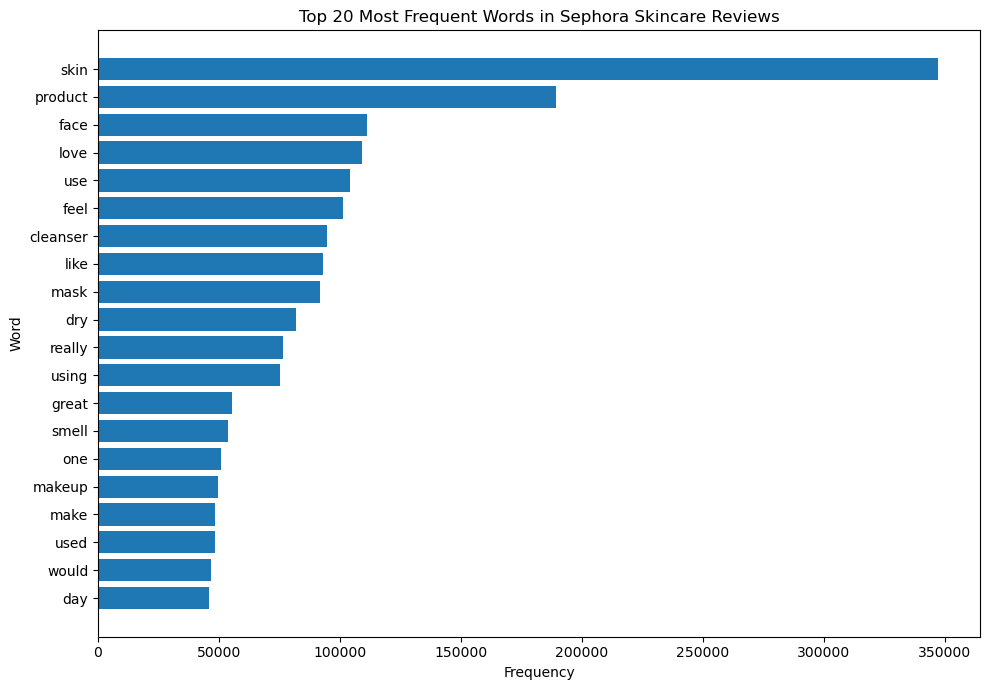

In [20]:
import matplotlib.pyplot as plt

# Get top 20 words
top_20 = word_counts.most_common(20)

words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in Sephora Skincare Reviews")

plt.tight_layout()
plt.show()

In [21]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


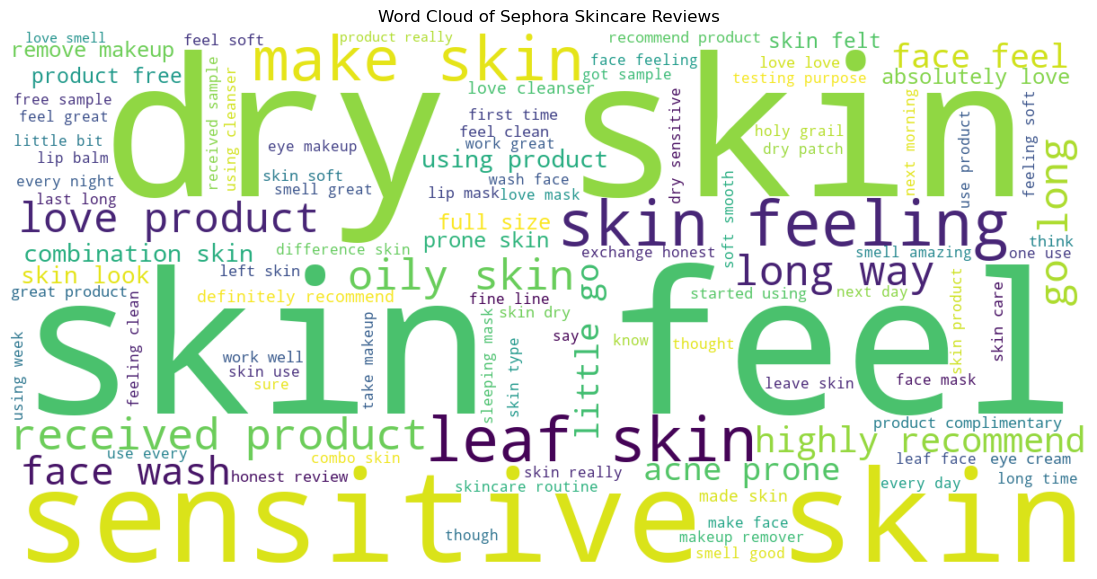

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all processed reviews into one text corpus
all_processed_text = " ".join(reviews_text["processed_text"])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(all_processed_text)

# Display Word Cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Sephora Skincare Reviews")
plt.show()

In [26]:
%pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [27]:
from textblob import TextBlob

# Test TextBlob sentiment analysis on 10 reviews
sentiment_test = reviews_text["review_text"].sample(10, random_state=42)

for i, text in enumerate(sentiment_test, start=1):
    sentiment = TextBlob(text).sentiment

    print(f"Review {i}")
    print("Polarity:", round(sentiment.polarity, 4))
    print("Subjectivity:", round(sentiment.subjectivity, 4))
    print("-" * 60)

Review 1
Polarity: 0.1738
Subjectivity: 0.4667
------------------------------------------------------------
Review 2
Polarity: 0.1496
Subjectivity: 0.4901
------------------------------------------------------------
Review 3
Polarity: 0.2042
Subjectivity: 0.6333
------------------------------------------------------------
Review 4
Polarity: 0.042
Subjectivity: 0.6451
------------------------------------------------------------
Review 5
Polarity: 0.3012
Subjectivity: 0.5107
------------------------------------------------------------
Review 6
Polarity: 0.0226
Subjectivity: 0.4167
------------------------------------------------------------
Review 7
Polarity: 0.3667
Subjectivity: 0.6667
------------------------------------------------------------
Review 8
Polarity: 0.2143
Subjectivity: 0.4588
------------------------------------------------------------
Review 9
Polarity: 0.3167
Subjectivity: 0.7472
------------------------------------------------------------
Review 10
Polarity: 0.1053
Su

In [28]:
from textblob import TextBlob

# Calculate polarity and subjectivity for every review
sentiment_scores = reviews_text["review_text"].apply(
    lambda text: TextBlob(text).sentiment
)

reviews_text["polarity"] = sentiment_scores.apply(lambda x: x.polarity)
reviews_text["subjectivity"] = sentiment_scores.apply(lambda x: x.subjectivity)

# Classify sentiment
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_text["sentiment"] = reviews_text["polarity"].apply(
    classify_sentiment
)

print("Sentiment analysis completed.")
print("Total reviews analyzed:", len(reviews_text))

print("\nSentiment counts:")
print(reviews_text["sentiment"].value_counts())

Sentiment analysis completed.
Total reviews analyzed: 285063

Sentiment counts:
sentiment
Positive    257177
Negative     23386
Neutral       4500
Name: count, dtype: int64


In [29]:
# Calculate sentiment distribution

sentiment_distribution = (
    reviews_text["sentiment"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Count")
)

sentiment_distribution["Percentage"] = (
    sentiment_distribution["Count"]
    / sentiment_distribution["Count"].sum()
    * 100
)

sentiment_distribution["Percentage"] = (
    sentiment_distribution["Percentage"].round(2)
)

print("Sentiment Distribution:")
display(sentiment_distribution)

print(
    "\nTotal percentage:",
    sentiment_distribution["Percentage"].sum()
)

Sentiment Distribution:


,Sentiment,Count,Percentage
0,Positive,257177,90.22
1,Negative,23386,8.20
2,Neutral,4500,1.58



Total percentage: 100.0


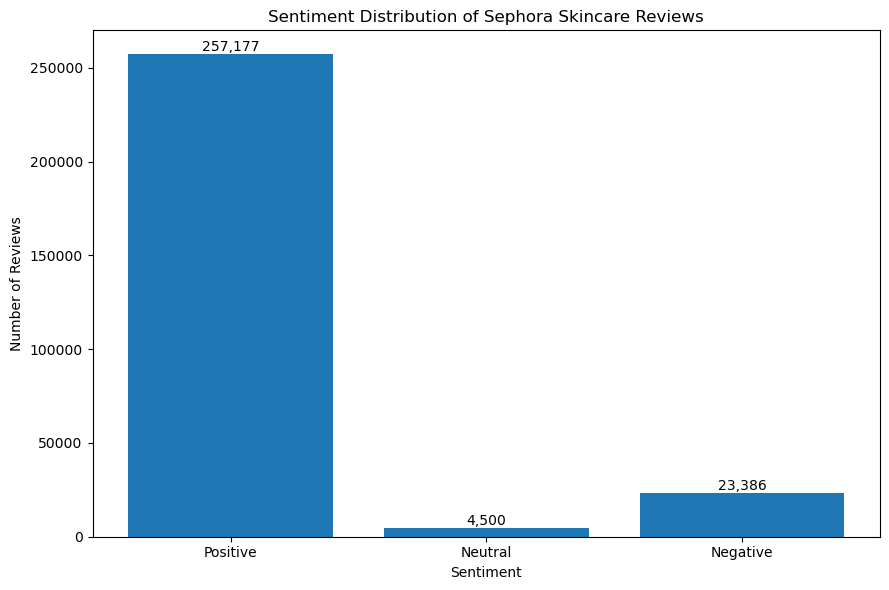

In [30]:
import matplotlib.pyplot as plt

# Prepare sentiment counts in a fixed logical order
sentiment_order = ["Positive", "Neutral", "Negative"]

sentiment_counts = (
    reviews_text["sentiment"]
    .value_counts()
    .reindex(sentiment_order)
)

# Create bar chart
plt.figure(figsize=(9, 6))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Sentiment Distribution of Sephora Skincare Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Add count labels
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [31]:
# Compare sentiment classification with average star rating

rating_by_sentiment = (
    reviews_text
    .groupby("sentiment")["rating"]
    .agg(["count", "mean", "median"])
    .reindex(["Positive", "Neutral", "Negative"])
    .round(2)
)

print("Rating statistics by TextBlob sentiment:")
display(rating_by_sentiment)

Rating statistics by TextBlob sentiment:


,count,mean,median
sentiment,,,
Positive,257177,4.44,5.0
Neutral,4500,3.81,5.0
Negative,23386,3.22,3.0


In [32]:
# Compare customer recommendation rate across sentiment classes

recommendation_by_sentiment = (
    reviews_text
    .dropna(subset=["is_recommended"])
    .groupby("sentiment")["is_recommended"]
    .agg(["count", "mean"])
    .reindex(["Positive", "Neutral", "Negative"])
)

recommendation_by_sentiment["recommendation_rate_%"] = (
    recommendation_by_sentiment["mean"] * 100
).round(2)

recommendation_by_sentiment = recommendation_by_sentiment[
    ["count", "recommendation_rate_%"]
]

print("Recommendation rate by TextBlob sentiment:")
display(recommendation_by_sentiment)

Recommendation rate by TextBlob sentiment:


,count,recommendation_rate_%
sentiment,,
Positive,206143,87.78
Neutral,3429,67.51
Negative,18259,49.26


In [33]:
# Create a rating-based sentiment benchmark

def rating_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

reviews_text["rating_sentiment"] = reviews_text["rating"].apply(
    rating_sentiment
)

# Compare TextBlob sentiment with rating-based sentiment
comparison = pd.crosstab(
    reviews_text["rating_sentiment"],
    reviews_text["sentiment"],
    normalize="index"
) * 100

comparison = comparison.reindex(
    index=["Positive", "Neutral", "Negative"],
    columns=["Positive", "Neutral", "Negative"]
)

comparison = comparison.round(2)

print("TextBlob Sentiment vs Rating-Based Sentiment (%)")
display(comparison)

# Calculate overall agreement
agreement = (
    reviews_text["sentiment"] ==
    reviews_text["rating_sentiment"]
).mean() * 100

print(f"\nOverall agreement: {agreement:.2f}%")

TextBlob Sentiment vs Rating-Based Sentiment (%)


sentiment,Positive,Neutral,Negative
rating_sentiment,,,
Positive,93.78,1.28,4.94
Neutral,86.11,1.80,12.10
Negative,63.04,3.93,33.02



Overall agreement: 81.04%


In [34]:
# Analyze the distribution of star ratings

rating_distribution = (
    reviews_text["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("Rating")
    .reset_index(name="Count")
)

rating_distribution["Percentage"] = (
    rating_distribution["Count"]
    / rating_distribution["Count"].sum()
    * 100
).round(2)

print("Star Rating Distribution:")
display(rating_distribution)

print(
    "\nAverage rating:",
    round(reviews_text["rating"].mean(), 2)
)

print(
    "Median rating:",
    reviews_text["rating"].median()
)

Star Rating Distribution:


,Rating,Count,Percentage
0,1,14621,5.13
1,2,13107,4.60
2,3,21148,7.42
3,4,50766,17.81
4,5,185421,65.05



Average rating: 4.33
Median rating: 5.0


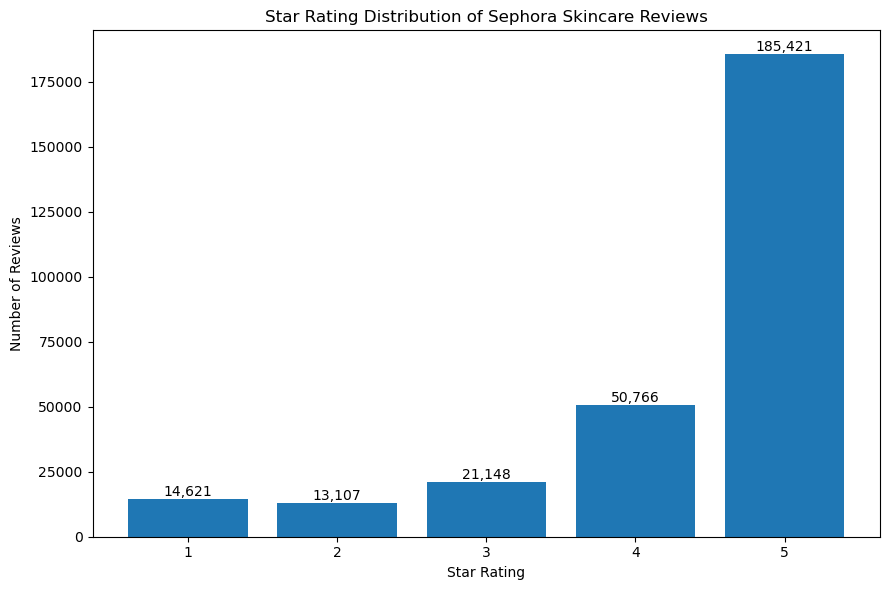

In [35]:
import matplotlib.pyplot as plt

# Create rating distribution chart

plt.figure(figsize=(9, 6))

bars = plt.bar(
    rating_distribution["Rating"].astype(str),
    rating_distribution["Count"]
)

plt.title("Star Rating Distribution of Sephora Skincare Reviews")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")

# Add count labels
for bar, count in zip(bars, rating_distribution["Count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [36]:
# Descriptive statistics for TextBlob polarity and subjectivity

polarity_stats = reviews_text["polarity"].describe().round(4)
subjectivity_stats = reviews_text["subjectivity"].describe().round(4)

print("POLARITY STATISTICS")
print("=" * 50)
display(polarity_stats)

print("\nSUBJECTIVITY STATISTICS")
print("=" * 50)
display(subjectivity_stats)

POLARITY STATISTICS


count    285063.0000
mean          0.2398
std           0.2013
min          -1.0000
25%           0.1208
50%           0.2333
75%           0.3541
max           1.0000
Name: polarity, dtype: float64


SUBJECTIVITY STATISTICS


count    285063.0000
mean          0.5676
std           0.1468
min           0.0000
25%           0.4877
50%           0.5713
75%           0.6537
max           1.0000
Name: subjectivity, dtype: float64

In [37]:
# Descriptive statistics for TextBlob polarity and subjectivity

polarity_stats = reviews_text["polarity"].describe().round(4)
subjectivity_stats = reviews_text["subjectivity"].describe().round(4)

print("POLARITY STATISTICS")
print("=" * 50)
display(polarity_stats)

print("\nSUBJECTIVITY STATISTICS")
print("=" * 50)
display(subjectivity_stats)

POLARITY STATISTICS


count    285063.0000
mean          0.2398
std           0.2013
min          -1.0000
25%           0.1208
50%           0.2333
75%           0.3541
max           1.0000
Name: polarity, dtype: float64


SUBJECTIVITY STATISTICS


count    285063.0000
mean          0.5676
std           0.1468
min           0.0000
25%           0.4877
50%           0.5713
75%           0.6537
max           1.0000
Name: subjectivity, dtype: float64

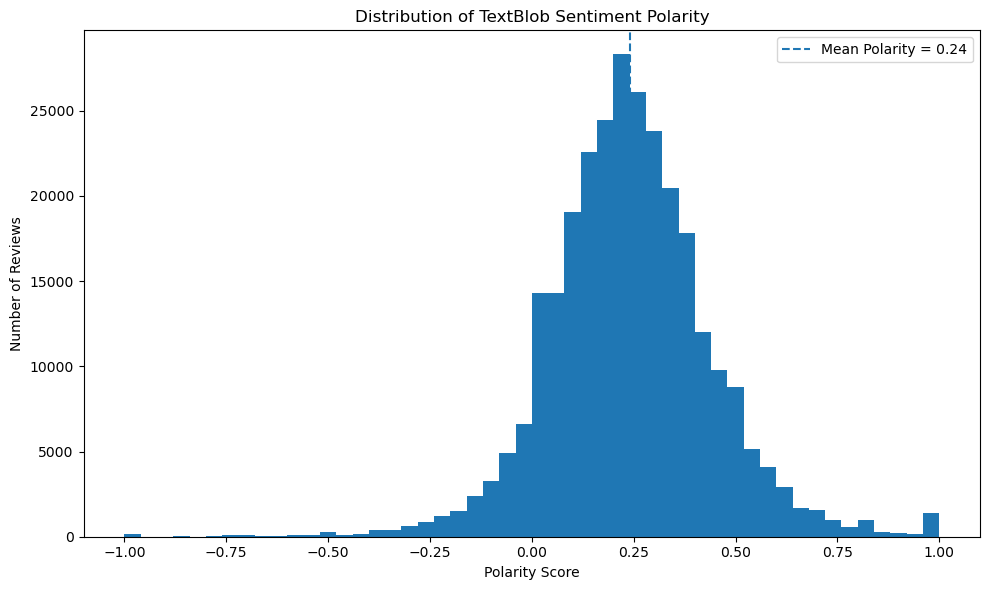

In [38]:
import matplotlib.pyplot as plt

# Plot distribution of TextBlob polarity scores

plt.figure(figsize=(10, 6))

plt.hist(
    reviews_text["polarity"],
    bins=50
)

plt.axvline(
    reviews_text["polarity"].mean(),
    linestyle="--",
    label=f"Mean Polarity = {reviews_text['polarity'].mean():.2f}"
)

plt.title("Distribution of TextBlob Sentiment Polarity")
plt.xlabel("Polarity Score")
plt.ylabel("Number of Reviews")
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
# Analyze average TextBlob polarity and subjectivity by star rating

sentiment_by_rating = (
    reviews_text
    .groupby("rating")
    .agg(
        review_count=("rating", "size"),
        average_polarity=("polarity", "mean"),
        median_polarity=("polarity", "median"),
        average_subjectivity=("subjectivity", "mean")
    )
    .round(4)
)

print("TextBlob sentiment metrics by star rating:")
display(sentiment_by_rating)

TextBlob sentiment metrics by star rating:


,review_count,average_polarity,median_polarity,average_subjectivity
rating,,,,
1,14621,0.0073,0.0194,0.5295
2,13107,0.1103,0.1141,0.5410
3,21148,0.1792,0.1781,0.5530
4,50766,0.2375,0.2278,0.5732
5,185421,0.2749,0.2625,0.5726


In [40]:
# Measure the relationship between star rating and TextBlob polarity

pearson_correlation = reviews_text["rating"].corr(
    reviews_text["polarity"],
    method="pearson"
)

spearman_correlation = reviews_text["rating"].corr(
    reviews_text["polarity"],
    method="spearman"
)

print("Pearson correlation:", round(pearson_correlation, 4))
print("Spearman correlation:", round(spearman_correlation, 4))

Pearson correlation: 0.3318
Spearman correlation: 0.273


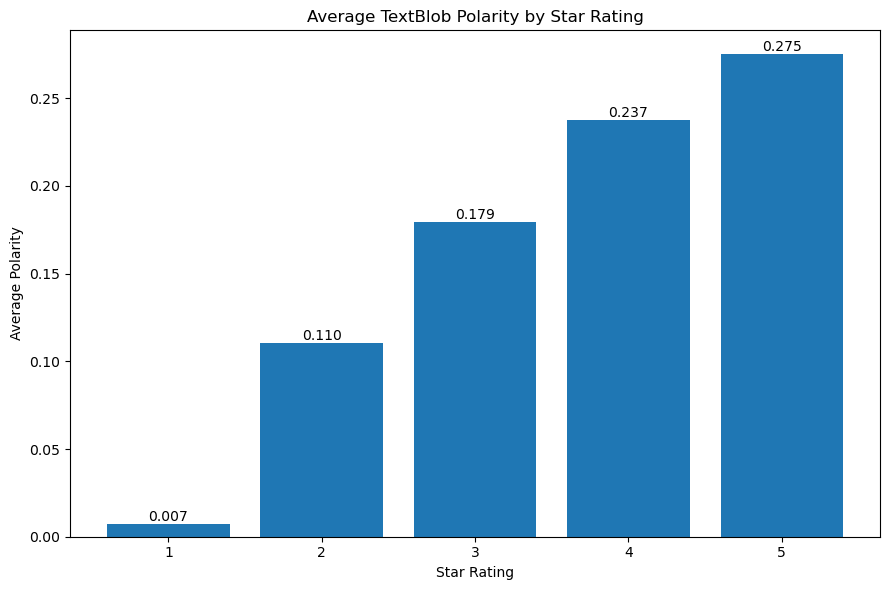

In [41]:
# Visualize average TextBlob polarity by star rating

plt.figure(figsize=(9, 6))

bars = plt.bar(
    sentiment_by_rating.index.astype(str),
    sentiment_by_rating["average_polarity"]
)

plt.title("Average TextBlob Polarity by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Polarity")

# Add polarity values above bars
for bar, value in zip(
    bars,
    sentiment_by_rating["average_polarity"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [42]:
from collections import Counter

# Calculate most frequent words within each sentiment group

sentiment_word_counts = {}

for sentiment in ["Positive", "Negative", "Neutral"]:
    tokens = [
        word
        for token_list in reviews_text.loc[
            reviews_text["sentiment"] == sentiment,
            "lemmatized_tokens"
        ]
        for word in token_list
    ]
    
    sentiment_word_counts[sentiment] = Counter(tokens)

# Display top 20 words for each sentiment
for sentiment in ["Positive", "Negative", "Neutral"]:
    print(f"\n{sentiment.upper()} REVIEWS")
    print("=" * 50)
    
    for rank, (word, count) in enumerate(
        sentiment_word_counts[sentiment].most_common(20),
        start=1
    ):
        print(f"{rank:2}. {word:<20} {count:,}")


POSITIVE REVIEWS
 1. skin                 321,707
 2. product              174,713
 3. love                 106,820
 4. face                 101,793
 5. use                  96,301
 6. feel                 95,992
 7. cleanser             88,953
 8. mask                 85,762
 9. like                 84,566
10. dry                  73,661
11. really               71,677
12. using                68,569
13. great                54,765
14. smell                49,816
15. one                  46,727
16. makeup               46,381
17. make                 45,281
18. used                 43,787
19. would                42,472
20. day                  41,411

NEGATIVE REVIEWS
 1. skin                 23,779
 2. product              13,651
 3. face                 8,684
 4. dry                  7,924
 5. like                 7,823
 6. use                  7,156
 7. using                6,256
 8. mask                 5,554
 9. cleanser             5,129
10. feel                 4,879
11. real

In [43]:
# Compare word frequency per 1,000 reviews
# This removes the bias caused by different sentiment-group sizes.

sentiment_sizes = reviews_text["sentiment"].value_counts()

normalized_word_frequency = {}

for sentiment in ["Positive", "Negative", "Neutral"]:
    total_reviews = sentiment_sizes[sentiment]
    
    normalized = {
        word: (count / total_reviews) * 1000
        for word, count in sentiment_word_counts[sentiment].items()
    }
    
    normalized_word_frequency[sentiment] = normalized

# Display the top 20 normalized words for each sentiment
for sentiment in ["Positive", "Negative", "Neutral"]:
    print(f"\n{sentiment.upper()} REVIEWS — FREQUENCY PER 1,000 REVIEWS")
    print("=" * 65)
    
    top_normalized = sorted(
        normalized_word_frequency[sentiment].items(),
        key=lambda x: x[1],
        reverse=True
    )[:20]
    
    for rank, (word, frequency) in enumerate(top_normalized, start=1):
        print(f"{rank:2}. {word:<20} {frequency:8.2f}")


POSITIVE REVIEWS — FREQUENCY PER 1,000 REVIEWS
 1. skin                  1250.92
 2. product                679.35
 3. love                   415.36
 4. face                   395.81
 5. use                    374.45
 6. feel                   373.25
 7. cleanser               345.88
 8. mask                   333.47
 9. like                   328.82
10. dry                    286.42
11. really                 278.71
12. using                  266.62
13. great                  212.95
14. smell                  193.70
15. one                    181.69
16. makeup                 180.35
17. make                   176.07
18. used                   170.26
19. would                  165.15
20. day                    161.02

NEGATIVE REVIEWS — FREQUENCY PER 1,000 REVIEWS
 1. skin                  1016.80
 2. product                583.73
 3. face                   371.33
 4. dry                    338.84
 5. like                   334.52
 6. use                    306.00
 7. using           

In [44]:
from collections import Counter

def get_bigrams(token_lists):
    bigram_counter = Counter()
    
    for tokens in token_lists:
        bigrams = zip(tokens, tokens[1:])
        bigram_counter.update(bigrams)
    
    return bigram_counter


# Create bigram frequencies for each sentiment group
sentiment_bigram_counts = {}

for sentiment in ["Positive", "Negative", "Neutral"]:
    token_lists = reviews_text.loc[
        reviews_text["sentiment"] == sentiment,
        "lemmatized_tokens"
    ]
    
    sentiment_bigram_counts[sentiment] = get_bigrams(token_lists)


# Display top 20 bigrams for each sentiment
for sentiment in ["Positive", "Negative", "Neutral"]:
    print(f"\n{sentiment.upper()} REVIEWS — TOP 20 BIGRAMS")
    print("=" * 65)
    
    for rank, (bigram, count) in enumerate(
        sentiment_bigram_counts[sentiment].most_common(20),
        start=1
    ):
        print(f"{rank:2}. {' '.join(bigram):<30} {count:,}")


POSITIVE REVIEWS — TOP 20 BIGRAMS
 1. skin feel                      26,257
 2. dry skin                       24,102
 3. sensitive skin                 23,363
 4. skin feeling                   14,490
 5. leaf skin                      14,234
 6. feel like                      13,893
 7. received product               13,663
 8. make skin                      13,427
 9. oily skin                      11,805
10. love product                   11,679
11. long way                       11,177
12. go long                        10,890
13. highly recommend               10,041
14. face wash                      9,919
15. face feel                      9,129
16. acne prone                     8,385
17. little go                      8,307
18. combination skin               8,017
19. skin look                      7,830
20. using product                  7,797

NEGATIVE REVIEWS — TOP 20 BIGRAMS
 1. dry skin                       2,284
 2. sensitive skin                 1,560
 3. skin feel  

In [45]:
# Analyze product-level negative sentiment
# Only products with at least 50 analyzed reviews are included.

product_sentiment = (
    reviews_text
    .groupby(["product_id", "product_name", "brand_name"])
    .agg(
        total_reviews=("sentiment", "size"),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate negative-review rate
product_sentiment["negative_rate_%"] = (
    product_sentiment["negative_reviews"]
    / product_sentiment["total_reviews"]
    * 100
).round(2)

# Keep products with at least 50 reviews
product_sentiment_50 = product_sentiment[
    product_sentiment["total_reviews"] >= 50
].copy()

# Sort by negative-review rate
top_negative_products = (
    product_sentiment_50
    .sort_values(
        ["negative_rate_%", "total_reviews"],
        ascending=[False, False]
    )
    .head(20)
)

print("Products with at least 50 analyzed reviews:", len(product_sentiment_50))

print("\nTop 20 products by negative-review rate:")
display(
    top_negative_products[
        [
            "product_name",
            "brand_name",
            "total_reviews",
            "negative_reviews",
            "negative_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ]
)

Products with at least 50 analyzed reviews: 380

Top 20 products by negative-review rate:


,product_name,brand_name,total_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
275,Saturn Sulfur + Niacinamide Spot Treatment Mask,Sunday Riley,99,31,31.31,3.151515,0.076994
193,Barrier+ Lip Repair Balm,Skinfix,64,16,25.00,3.015625,0.128032
19,Super Spot Remover Acne Treatment Gel,Origins,1703,372,21.84,3.935408,0.135990
137,pores no more Vacuum Cleaner Pore Purifying Mask,Dr. Brandt Skincare,239,52,21.76,3.887029,0.128711
109,Wrinkle Warrior Eye Gel Visible Dark Circle Eraser,Kate Somerville,89,19,21.35,3.089888,0.103953
81,24K Gold Pure Luxury Lift & Firm Hydra-Gel Eye Patches,Peter Thomas Roth,321,67,20.87,3.741433,0.168535
211,Instant Magic Facial Dry Sheet Mask,Charlotte Tilbury,53,11,20.75,3.490566,0.186282
190,Self Tan Purity Water Gel,St. Tropez,58,12,20.69,3.310345,0.136498
125,Hyaluronic Marine Dew It Right Eye Gel,Dr. Dennis Gross Skincare,148,30,20.27,3.527027,0.142333
175,Acne Facial Cleanser,Mario Badescu,79,16,20.25,3.759494,0.159549


In [46]:
# Analyze product-level positive sentiment

product_sentiment["positive_reviews"] = (
    reviews_text
    .groupby(["product_id", "product_name", "brand_name"])["sentiment"]
    .apply(lambda x: (x == "Positive").sum())
    .values
)

# Calculate positive-review rate
product_sentiment["positive_rate_%"] = (
    product_sentiment["positive_reviews"]
    / product_sentiment["total_reviews"]
    * 100
).round(2)

# Keep products with at least 50 reviews
product_sentiment_50 = product_sentiment[
    product_sentiment["total_reviews"] >= 50
].copy()

# Sort by positive-review rate
top_positive_products = (
    product_sentiment_50
    .sort_values(
        ["positive_rate_%", "total_reviews"],
        ascending=[False, False]
    )
    .head(20)
)

print("Products with at least 50 analyzed reviews:", len(product_sentiment_50))

print("\nTop 20 products by positive-review rate:")
display(
    top_positive_products[
        [
            "product_name",
            "brand_name",
            "total_reviews",
            "positive_reviews",
            "positive_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ]
)

Products with at least 50 analyzed reviews: 380

Top 20 products by positive-review rate:


,product_name,brand_name,total_reviews,positive_reviews,positive_rate_%,average_rating,average_polarity
330,KateCeuticals Total Repair Cream,Kate Somerville,91,91,100.00,4.714286,0.306958
434,Liftwear Brightening Vitamin C Gel-Cream,FaceGym,77,77,100.00,4.675325,0.355350
401,Electro-Lite Enzyme Brightening Gel Cleanser,FaceGym,71,71,100.00,4.788732,0.335404
344,Equilibrium Rebalancing Cream Cleanser,Hourglass,55,55,100.00,4.400000,0.264399
491,GinZing Energizing Gel Cream with Caffeine & Niacinamide,Origins,119,118,99.16,4.596639,0.348172
529,The POREfessional Good Cleanup Foaming Cleanser,Benefit Cosmetics,463,459,99.14,4.622030,0.297194
463,Gentle Micellar Antioxidant Cleanser,The Outset,112,111,99.11,4.660714,0.324496
325,Milky Mushroom Gentle Cleansing Oil Makeup Remover,KORA Organics,459,453,98.69,4.459695,0.282649
406,NUDESKIN Citrus-C Mask & Daily Moisturizer,NUDESTIX,73,72,98.63,4.260274,0.257819
532,The POREfessional Speedy Smooth Mask,Benefit Cosmetics,471,464,98.51,4.713376,0.295127


In [47]:
# Rank products by absolute number of negative reviews

top_negative_volume = (
    product_sentiment_50
    .sort_values(
        ["negative_reviews", "total_reviews"],
        ascending=[False, False]
    )
    .head(20)
)

print("Top 20 products by number of negative reviews:")

display(
    top_negative_volume[
        [
            "product_name",
            "brand_name",
            "total_reviews",
            "negative_reviews",
            "negative_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ]
)

Top 20 products by number of negative reviews:


,product_name,brand_name,total_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
107,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,16084,1614,10.03,4.349105,0.237618
15,Ultra Repair Cream Intense Hydration,First Aid Beauty,7545,926,12.27,4.518489,0.196879
538,Soy Hydrating Gentle Face Cleanser,fresh,8730,521,5.97,4.362658,0.255558
139,Jet Lag Mask,Summer Fridays,4419,499,11.29,4.026024,0.208810
433,Mini Jet Lag Mask,Summer Fridays,4419,499,11.29,4.026024,0.208810
90,Superfood Antioxidant Cleanser,Youth To The People,5852,465,7.95,4.210526,0.248852
185,Mini Superfood Antioxidant Cleanser,Youth To The People,5842,465,7.96,4.211400,0.248715
14,Pure Skin Face Cleanser,First Aid Beauty,4728,410,8.67,4.373731,0.223829
20,Clear Improvement Active Charcoal Mask to Clear Pores,Origins,4525,379,8.38,4.329061,0.230240
19,Super Spot Remover Acne Treatment Gel,Origins,1703,372,21.84,3.935408,0.135990


In [48]:
# Check for product names associated with multiple product IDs

duplicate_product_names = (
    reviews_text
    .groupby("product_name")["product_id"]
    .nunique()
    .reset_index(name="unique_product_ids")
)

duplicate_product_names = (
    duplicate_product_names[
        duplicate_product_names["unique_product_ids"] > 1
    ]
    .sort_values("unique_product_ids", ascending=False)
)

print(
    "Product names associated with multiple product IDs:",
    len(duplicate_product_names)
)

print("\nExamples:")
display(duplicate_product_names.head(20))

Product names associated with multiple product IDs: 1

Examples:


,product_name,unique_product_ids
252,Lip Sleeping Mask,2


In [49]:
# Brand-level sentiment analysis
# Only brands with at least 100 analyzed reviews are included.

brand_sentiment = (
    reviews_text
    .groupby("brand_name")
    .agg(
        total_reviews=("sentiment", "size"),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate sentiment rates
brand_sentiment["positive_rate_%"] = (
    brand_sentiment["positive_reviews"]
    / brand_sentiment["total_reviews"]
    * 100
).round(2)

brand_sentiment["negative_rate_%"] = (
    brand_sentiment["negative_reviews"]
    / brand_sentiment["total_reviews"]
    * 100
).round(2)

# Filter brands with sufficient review volume
brand_sentiment_100 = brand_sentiment[
    brand_sentiment["total_reviews"] >= 100
].copy()

print(
    "Brands with at least 100 analyzed reviews:",
    len(brand_sentiment_100)
)

# Top 20 brands by negative-review rate
top_negative_brands = (
    brand_sentiment_100
    .sort_values(
        ["negative_rate_%", "total_reviews"],
        ascending=[False, False]
    )
    .head(20)
)

print("\nTop 20 brands by negative-review rate:")
display(
    top_negative_brands[
        [
            "brand_name",
            "total_reviews",
            "negative_reviews",
            "negative_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ]
)

Brands with at least 100 analyzed reviews: 82

Top 20 brands by negative-review rate:


,brand_name,total_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
51,Mario Badescu,245,41,16.73,3.881633,0.190597
11,Charlotte Tilbury,151,24,15.89,3.668874,0.186220
77,St. Tropez,139,21,15.11,4.021583,0.214577
37,INC.redible,106,16,15.09,3.877358,0.208148
34,Herbivore,1994,251,12.59,4.259278,0.173132
22,Drunk Elephant,8331,1018,12.22,4.076822,0.190941
17,Dr. Barbara Sturm,225,27,12.00,4.137778,0.180049
5,Biossance,4253,499,11.73,4.087468,0.204164
90,Wander Beauty,558,63,11.29,4.084229,0.228795
87,The Ordinary,1014,114,11.24,4.003945,0.213135


In [50]:
# Identify words disproportionately associated with negative reviews

positive_total = sentiment_sizes["Positive"]
negative_total = sentiment_sizes["Negative"]

# Get normalized frequency per review
negative_words = sentiment_word_counts["Negative"]
positive_words = sentiment_word_counts["Positive"]

negative_word_ratio = []

for word, neg_count in negative_words.items():
    
    # Minimum negative frequency threshold
    if neg_count >= 100:
        
        neg_rate = neg_count / negative_total
        pos_count = positive_words.get(word, 0)
        pos_rate = pos_count / positive_total
        
        # Avoid division by zero
        if pos_rate > 0:
            ratio = neg_rate / pos_rate
            
            negative_word_ratio.append(
                (word, neg_count, neg_rate, pos_count, pos_rate, ratio)
            )

# Convert to DataFrame
negative_word_ratio_df = pd.DataFrame(
    negative_word_ratio,
    columns=[
        "word",
        "negative_count",
        "negative_rate",
        "positive_count",
        "positive_rate",
        "negative_to_positive_ratio"
    ]
)

# Sort by ratio
top_negative_associated_words = (
    negative_word_ratio_df
    .sort_values(
        ["negative_to_positive_ratio", "negative_count"],
        ascending=[False, False]
    )
    .head(30)
)

print("Top 30 words disproportionately associated with negative reviews:")

display(
    top_negative_associated_words[
        [
            "word",
            "negative_count",
            "negative_to_positive_ratio"
        ]
    ]
)

Top 30 words disproportionately associated with negative reviews:


,word,negative_count,negative_to_positive_ratio
170,worst,842,16.896926
236,disgusting,120,15.168344
103,awful,695,14.754729
46,horrible,1014,13.869413
155,terrible,938,13.024283
573,hated,244,10.125585
273,batch,102,9.669819
499,terribly,198,9.592140
199,badly,407,8.707780
292,horribly,175,8.477902


In [51]:
# Identify words disproportionately associated with positive reviews

positive_word_ratio = []

for word, pos_count in positive_words.items():
    
    # Minimum positive frequency threshold
    if pos_count >= 500:
        
        pos_rate = pos_count / positive_total
        neg_count = negative_words.get(word, 0)
        neg_rate = neg_count / negative_total
        
        # Avoid division by zero
        if neg_rate > 0:
            ratio = pos_rate / neg_rate
            
            positive_word_ratio.append(
                (word, pos_count, pos_rate, neg_count, neg_rate, ratio)
            )

# Convert to DataFrame
positive_word_ratio_df = pd.DataFrame(
    positive_word_ratio,
    columns=[
        "word",
        "positive_count",
        "positive_rate",
        "negative_count",
        "negative_rate",
        "positive_to_negative_ratio"
    ]
)

# Sort by ratio
top_positive_associated_words = (
    positive_word_ratio_df
    .sort_values(
        ["positive_to_negative_ratio", "positive_count"],
        ascending=[False, False]
    )
    .head(30)
)

print("Top 30 words disproportionately associated with positive reviews:")

display(
    top_positive_associated_words[
        [
            "word",
            "positive_count",
            "positive_to_negative_ratio"
        ]
    ]
)

Top 30 words disproportionately associated with positive reviews:


,word,positive_count,positive_to_negative_ratio
416,excellent,1877,14.223512
173,perfect,13066,13.815545
726,wonderful,4897,12.035169
557,beautiful,3952,11.978971
398,gifted,4934,11.504251
792,awesome,3595,10.896862
63,best,19709,10.667905
162,delicious,884,10.048150
1289,flawless,828,9.411615
1390,kora,619,9.381304


In [52]:
# Inspect skincare product information columns

print("product_info_skincare shape:", product_info_skincare.shape)

print("\nColumns:")
for col in product_info_skincare.columns:
    print(col)

product_info_skincare shape: (1813, 28)

Columns:
Unnamed: 0
product_id
product_name
brand_id
brand_name
loves_count
rating
reviews
size
variation_type
variation_value
variation_desc
ingredients
price_usd
value_price_usd
sale_price_usd
limited_edition
new
online_only
out_of_stock
sephora_exclusive
highlights
primary_category
secondary_category
tertiary_category
child_count
child_max_price
child_min_price


In [53]:
# Check whether product_id is unique in the skincare product dataset

total_product_rows = len(product_info_skincare)

unique_product_ids = product_info_skincare["product_id"].nunique()

duplicate_product_id_rows = (
    product_info_skincare["product_id"].duplicated().sum()
)

print("Total product rows:", total_product_rows)
print("Unique product IDs:", unique_product_ids)
print("Duplicate product ID rows:", duplicate_product_id_rows)

Total product rows: 1813
Unique product IDs: 1813
Duplicate product ID rows: 0


In [54]:
# Select category information from the skincare product dataset

product_categories = product_info_skincare[
    [
        "product_id",
        "primary_category",
        "secondary_category",
        "tertiary_category"
    ]
].copy()

# Merge category information into the review dataset
reviews_text = reviews_text.merge(
    product_categories,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Merged dataset shape:", reviews_text.shape)

print("\nCategory columns added:")
print(
    reviews_text[
        ["primary_category", "secondary_category", "tertiary_category"]
    ].columns.tolist()
)

print("\nMissing category values:")
print(
    reviews_text[
        ["primary_category", "secondary_category", "tertiary_category"]
    ].isna().sum()
)

Merged dataset shape: (285063, 33)

Category columns added:
['primary_category', 'secondary_category', 'tertiary_category']

Missing category values:
primary_category          0
secondary_category        0
tertiary_category     54004
dtype: int64


In [55]:
# Analyze review distribution across primary skincare categories

category_distribution = (
    reviews_text
    .groupby("primary_category")
    .agg(
        total_reviews=("sentiment", "size"),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate sentiment percentages
category_distribution["positive_rate_%"] = (
    category_distribution["positive_reviews"]
    / category_distribution["total_reviews"]
    * 100
).round(2)

category_distribution["negative_rate_%"] = (
    category_distribution["negative_reviews"]
    / category_distribution["total_reviews"]
    * 100
).round(2)

category_distribution["neutral_rate_%"] = (
    category_distribution["neutral_reviews"]
    / category_distribution["total_reviews"]
    * 100
).round(2)

# Sort by review volume
category_distribution = category_distribution.sort_values(
    "total_reviews",
    ascending=False
)

print("Primary category distribution and sentiment:")
display(category_distribution)

Primary category distribution and sentiment:


,primary_category,total_reviews,positive_reviews,negative_reviews,neutral_reviews,average_rating,average_polarity,positive_rate_%,negative_rate_%,neutral_rate_%
0,Skincare,285063,257177,23386,4500,4.330439,0.23981,90.22,8.2,1.58


In [57]:
# Analyze review distribution across secondary skincare categories

secondary_distribution = (
    reviews_text
    .groupby("secondary_category")
    .agg(
        total_reviews=("sentiment", "size"),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate sentiment percentages
secondary_distribution["positive_rate_%"] = (
    secondary_distribution["positive_reviews"]
    / secondary_distribution["total_reviews"]
    * 100
).round(2)

secondary_distribution["negative_rate_%"] = (
    secondary_distribution["negative_reviews"]
    / secondary_distribution["total_reviews"]
    * 100
).round(2)

secondary_distribution["neutral_rate_%"] = (
    secondary_distribution["neutral_reviews"]
    / secondary_distribution["total_reviews"]
    * 100
).round(2)

# Sort by review volume
secondary_distribution = secondary_distribution.sort_values(
    "total_reviews",
    ascending=False
)

print("Number of secondary categories:", len(secondary_distribution))

print("\nSecondary category distribution and sentiment:")
display(secondary_distribution)

Number of secondary categories: 13

Secondary category distribution and sentiment:


,secondary_category,total_reviews,positive_reviews,negative_reviews,neutral_reviews,average_rating,average_polarity,positive_rate_%,negative_rate_%,neutral_rate_%
0,Cleansers,90602,82644,6694,1264,4.334838,0.246028,91.22,7.39,1.40
4,Masks,69386,62499,5760,1127,4.343585,0.234856,90.07,8.30,1.62
6,Moisturizers,42931,39017,3355,559,4.403019,0.247582,90.88,7.81,1.30
5,Mini Size,31205,27964,2732,509,4.315270,0.236401,89.61,8.76,1.63
3,Lip Balms & Treatments,21314,18731,2134,449,4.308952,0.235281,87.88,10.01,2.11
10,Treatments,16322,14360,1604,358,4.212229,0.218857,87.98,9.83,2.19
1,Eye Care,10981,9829,953,199,4.215736,0.233860,89.51,8.68,1.81
11,Value & Gift Sets,1339,1253,67,19,4.258402,0.280100,93.58,5.00,1.42
9,Sunscreen,283,265,13,5,4.257951,0.288455,93.64,4.59,1.77
2,High Tech Tools,271,248,20,3,4.206642,0.235729,91.51,7.38,1.11


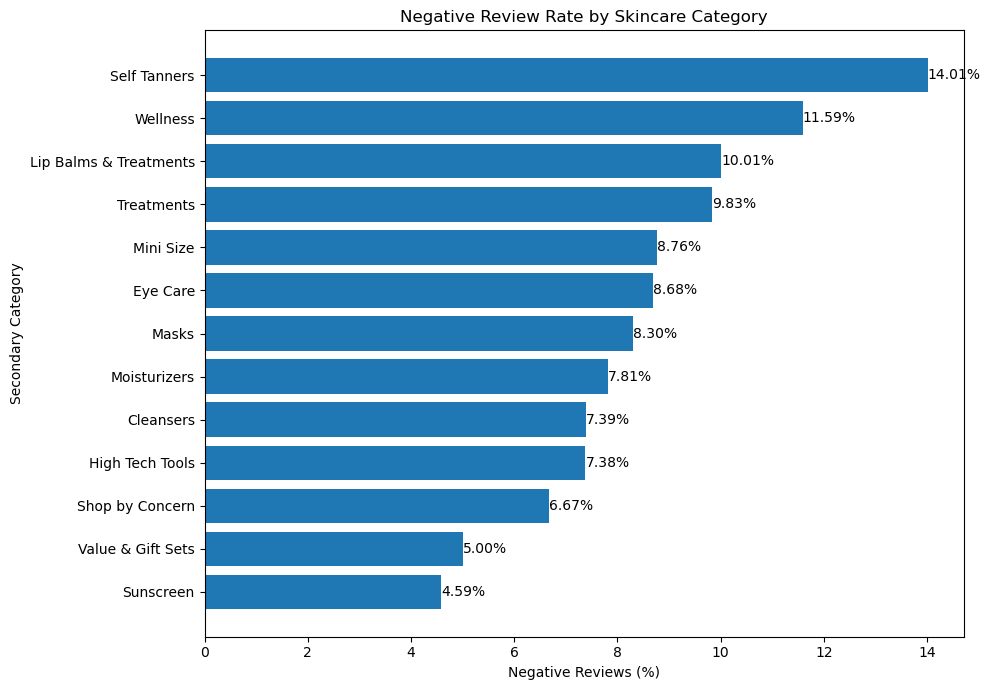

In [58]:
# Visualize negative-review rate by secondary category

category_chart_data = (
    secondary_distribution
    .sort_values("negative_rate_%", ascending=True)
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    category_chart_data["secondary_category"],
    category_chart_data["negative_rate_%"]
)

plt.title("Negative Review Rate by Skincare Category")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Secondary Category")

# Add percentage labels
for bar, value in zip(
    bars,
    category_chart_data["negative_rate_%"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [59]:
# Focus on secondary categories with substantial review volume

high_volume_categories = (
    secondary_distribution[
        secondary_distribution["total_reviews"] >= 1000
    ]
    .sort_values(
        "negative_rate_%",
        ascending=False
    )
    .copy()
)

print("Secondary categories with at least 1,000 reviews:")
print("=" * 70)

display(
    high_volume_categories[
        [
            "secondary_category",
            "total_reviews",
            "positive_reviews",
            "negative_reviews",
            "negative_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ]
)

Secondary categories with at least 1,000 reviews:


,secondary_category,total_reviews,positive_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
3,Lip Balms & Treatments,21314,18731,2134,10.01,4.308952,0.235281
10,Treatments,16322,14360,1604,9.83,4.212229,0.218857
5,Mini Size,31205,27964,2732,8.76,4.315270,0.236401
1,Eye Care,10981,9829,953,8.68,4.215736,0.233860
4,Masks,69386,62499,5760,8.30,4.343585,0.234856
6,Moisturizers,42931,39017,3355,7.81,4.403019,0.247582
0,Cleansers,90602,82644,6694,7.39,4.334838,0.246028
11,Value & Gift Sets,1339,1253,67,5.00,4.258402,0.280100


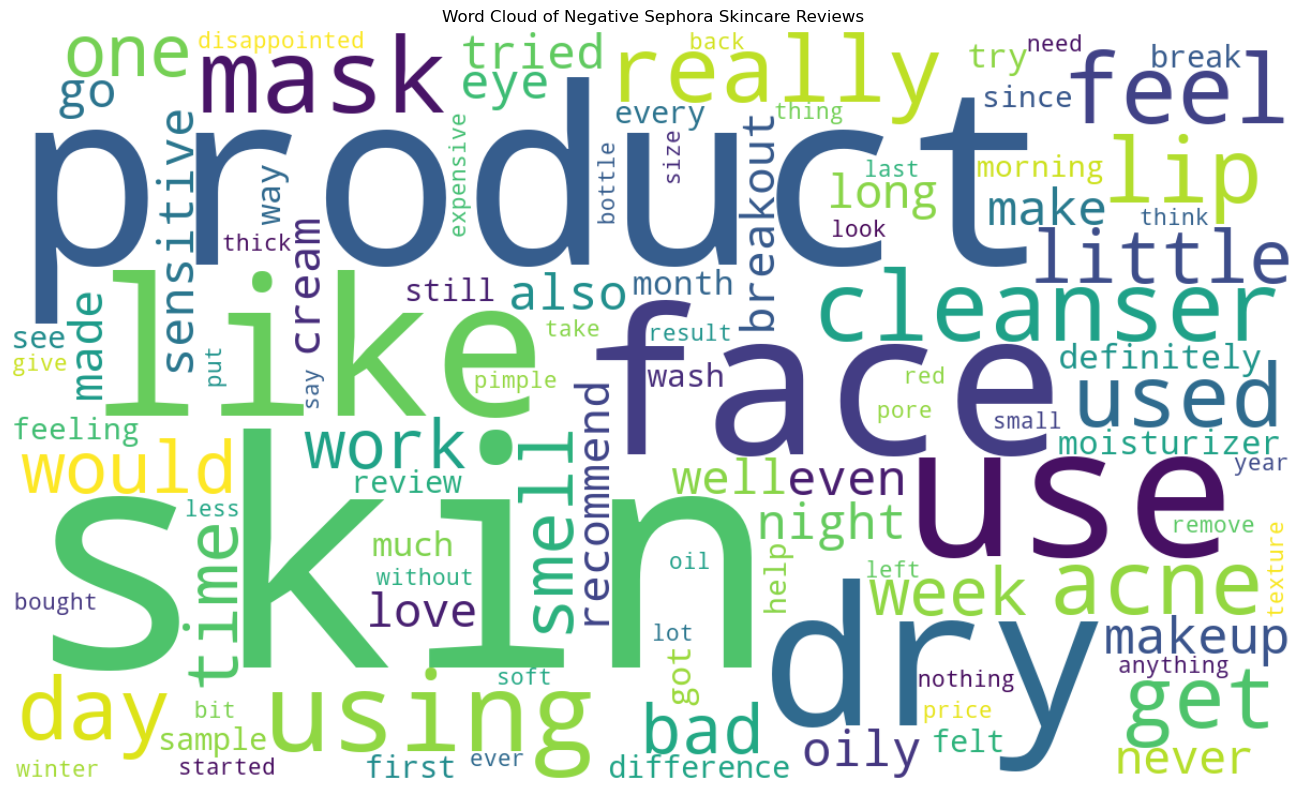

In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud from negative-review word frequencies

negative_wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(
    sentiment_word_counts["Negative"]
)

plt.figure(figsize=(14, 8))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Sephora Skincare Reviews")

plt.tight_layout()
plt.show()

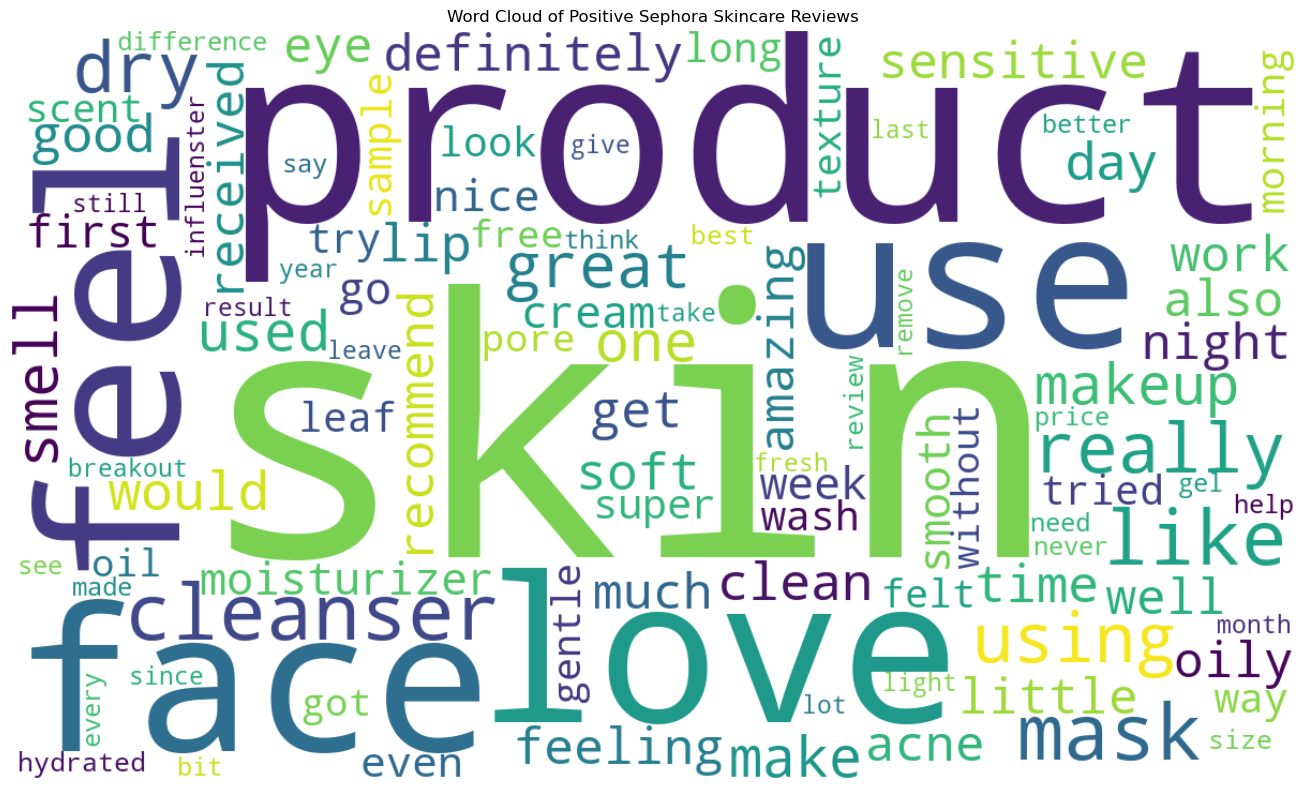

In [61]:
# Generate word cloud from positive-review word frequencies

positive_wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    collocations=False
).generate_from_frequencies(
    sentiment_word_counts["Positive"]
)

plt.figure(figsize=(14, 8))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Sephora Skincare Reviews")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

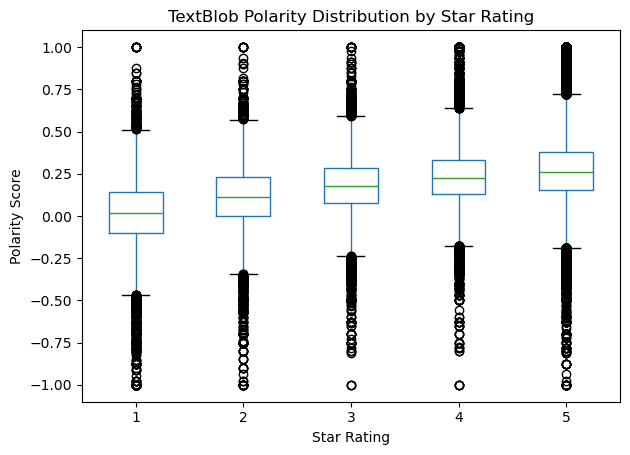

In [62]:
# Visualize the distribution of TextBlob polarity across star ratings

plt.figure(figsize=(10, 6))

reviews_text.boxplot(
    column="polarity",
    by="rating",
    grid=False
)

plt.suptitle("")
plt.title("TextBlob Polarity Distribution by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Polarity Score")

plt.tight_layout()
plt.show()

In [63]:
# Identify bigrams disproportionately associated with negative reviews

positive_bigram_counts = sentiment_bigram_counts["Positive"]
negative_bigram_counts = sentiment_bigram_counts["Negative"]

positive_total_reviews = sentiment_sizes["Positive"]
negative_total_reviews = sentiment_sizes["Negative"]

negative_bigram_ratio = []

for bigram, neg_count in negative_bigram_counts.items():

    # Require at least 50 occurrences in negative reviews
    if neg_count >= 50:

        neg_rate = neg_count / negative_total_reviews

        pos_count = positive_bigram_counts.get(bigram, 0)
        pos_rate = pos_count / positive_total_reviews

        if pos_rate > 0:

            ratio = neg_rate / pos_rate

            negative_bigram_ratio.append(
                (
                    bigram,
                    neg_count,
                    ratio
                )
            )

# Convert to DataFrame
negative_bigram_ratio_df = pd.DataFrame(
    negative_bigram_ratio,
    columns=[
        "bigram",
        "negative_count",
        "negative_to_positive_ratio"
    ]
)

# Sort by disproportionate association
top_negative_bigrams = (
    negative_bigram_ratio_df
    .sort_values(
        ["negative_to_positive_ratio", "negative_count"],
        ascending=[False, False]
    )
    .head(30)
)

print("Top 30 bigrams disproportionately associated with negative reviews:")
display(top_negative_bigrams)

Top 30 bigrams disproportionately associated with negative reviews:


,bigram,negative_count,negative_to_positive_ratio
377,"(worst, product)",69,58.368955
757,"(broke, terribly)",50,30.547360
706,"(break, bad)",67,23.025072
874,"(one, worst)",56,22.808695
409,"(broke, bad)",99,21.774158
684,"(smell, horrible)",117,19.203803
691,"(horrible, breakout)",50,18.960430
432,"(smell, awful)",126,18.724706
591,"(smell, terrible)",106,15.968318
101,"(bad, batch)",83,15.470426


In [64]:
# Identify bigrams disproportionately associated with positive reviews

positive_bigram_ratio = []

for bigram, pos_count in positive_bigram_counts.items():

    # Require at least 100 occurrences in positive reviews
    if pos_count >= 100:

        pos_rate = pos_count / positive_total_reviews

        neg_count = negative_bigram_counts.get(bigram, 0)
        neg_rate = neg_count / negative_total_reviews

        if neg_rate > 0:

            ratio = pos_rate / neg_rate

            positive_bigram_ratio.append(
                (
                    bigram,
                    pos_count,
                    ratio
                )
            )

# Convert to DataFrame
positive_bigram_ratio_df = pd.DataFrame(
    positive_bigram_ratio,
    columns=[
        "bigram",
        "positive_count",
        "positive_to_negative_ratio"
    ]
)

# Sort by disproportionate association
top_positive_bigrams = (
    positive_bigram_ratio_df
    .sort_values(
        ["positive_to_negative_ratio", "positive_count"],
        ascending=[False, False]
    )
    .head(30)
)

print("Top 30 bigrams disproportionately associated with positive reviews:")
display(top_positive_bigrams)

Top 30 bigrams disproportionately associated with positive reviews:


,bigram,positive_count,positive_to_negative_ratio
4070,"(best, part)",755,68.654779
5617,"(purpose, opinion)",753,68.472912
6108,"(nice, clean)",700,63.653437
1131,"(super, easy)",640,58.197428
7171,"(best, makeup)",530,48.194745
6404,"(cleanser, perfect)",514,46.739810
3516,"(super, light)",489,44.466473
7003,"(cleanser, super)",482,43.829938
8537,"(kora, organic)",464,42.193135
6183,"(best, face)",926,42.102202


In [65]:
# Inspect the review submission dates

date_series = pd.to_datetime(
    reviews_text["submission_time"],
    errors="coerce"
)

print("Minimum review date:", date_series.min())
print("Maximum review date:", date_series.max())

print("\nInvalid/unparsed dates:", date_series.isna().sum())

Minimum review date: 2008-08-28 00:00:00
Maximum review date: 2023-03-21 00:00:00

Invalid/unparsed dates: 0


In [66]:
# Create year-wise sentiment metrics

reviews_text["review_year"] = pd.to_datetime(
    reviews_text["submission_time"]
).dt.year

yearly_sentiment = (
    reviews_text
    .groupby("review_year")
    .agg(
        total_reviews=("sentiment", "size"),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate sentiment percentages
yearly_sentiment["positive_rate_%"] = (
    yearly_sentiment["positive_reviews"]
    / yearly_sentiment["total_reviews"]
    * 100
).round(2)

yearly_sentiment["negative_rate_%"] = (
    yearly_sentiment["negative_reviews"]
    / yearly_sentiment["total_reviews"]
    * 100
).round(2)

yearly_sentiment["neutral_rate_%"] = (
    yearly_sentiment["neutral_reviews"]
    / yearly_sentiment["total_reviews"]
    * 100
).round(2)

print("Year-wise sentiment analysis:")
display(yearly_sentiment)

Year-wise sentiment analysis:


,review_year,total_reviews,positive_reviews,negative_reviews,neutral_reviews,average_rating,average_polarity,positive_rate_%,negative_rate_%,neutral_rate_%
0,2008,903,816,70,17,4.486157,0.271096,90.37,7.75,1.88
1,2009,2864,2594,202,68,4.484986,0.259224,90.57,7.05,2.37
2,2010,3990,3586,318,86,4.512782,0.248379,89.87,7.97,2.16
3,2011,3706,3343,286,77,4.521587,0.236868,90.21,7.72,2.08
4,2012,3649,3277,306,66,4.488627,0.233602,89.81,8.39,1.81
5,2013,5155,4571,487,97,4.424636,0.218838,88.67,9.45,1.88
6,2014,6980,6128,700,152,4.401003,0.213494,87.79,10.03,2.18
7,2015,8523,7510,874,139,4.331691,0.211307,88.11,10.25,1.63
8,2016,11898,10619,1062,217,4.373676,0.224882,89.25,8.93,1.82
9,2017,16675,15039,1353,283,4.433943,0.237159,90.19,8.11,1.70


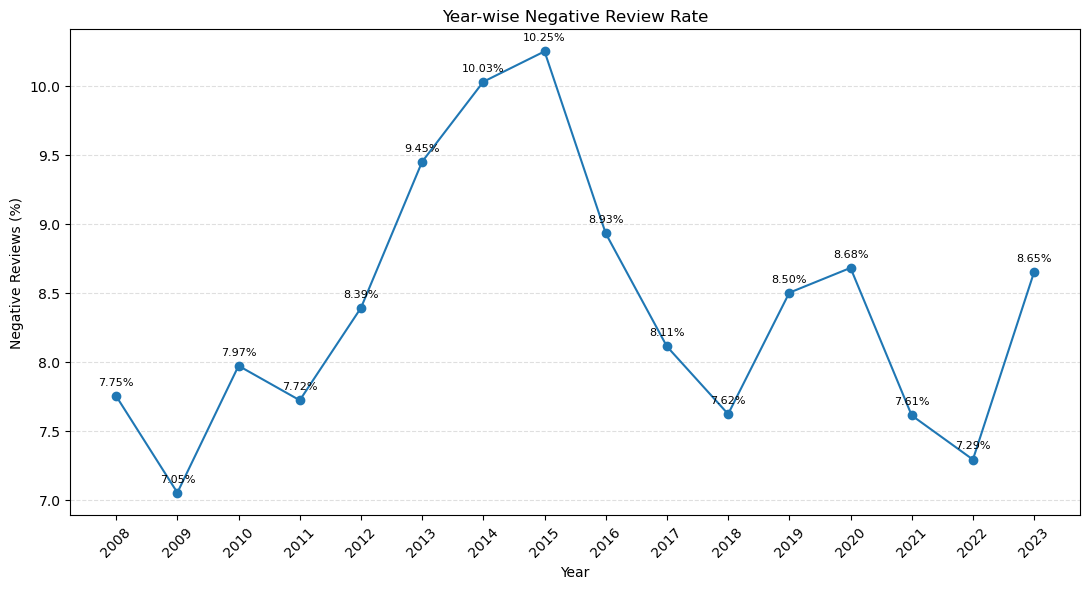

In [67]:
# Visualize the yearly negative-review rate

plt.figure(figsize=(11, 6))

plt.plot(
    yearly_sentiment["review_year"],
    yearly_sentiment["negative_rate_%"],
    marker="o"
)

plt.title("Year-wise Negative Review Rate")
plt.xlabel("Year")
plt.ylabel("Negative Reviews (%)")

# Add value labels
for year, value in zip(
    yearly_sentiment["review_year"],
    yearly_sentiment["negative_rate_%"]
):
    plt.annotate(
        f"{value:.2f}%",
        (year, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(yearly_sentiment["review_year"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

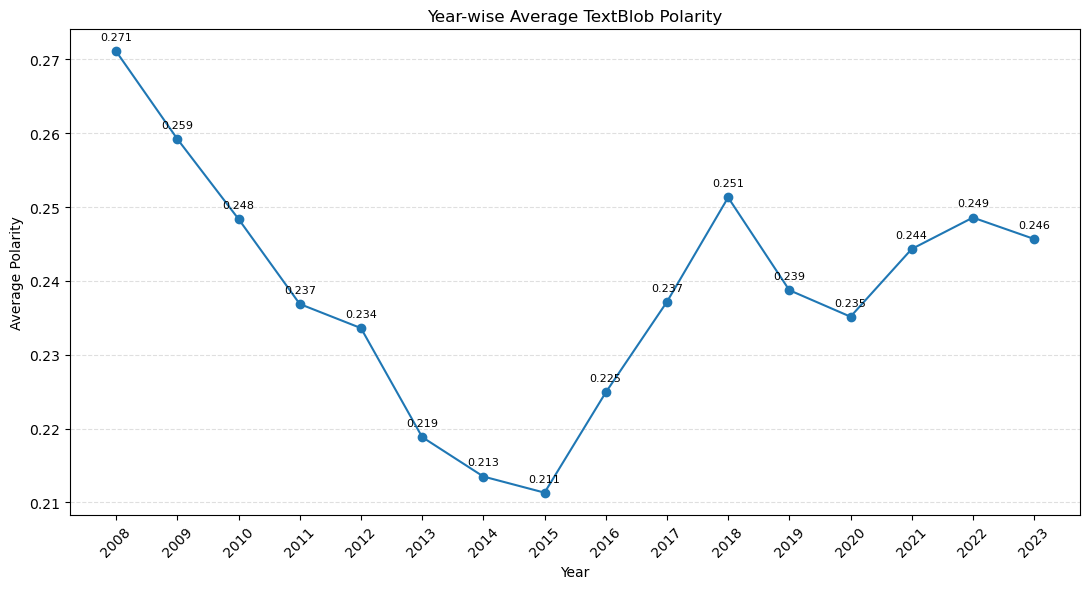

In [68]:
# Visualize average TextBlob polarity by year

plt.figure(figsize=(11, 6))

plt.plot(
    yearly_sentiment["review_year"],
    yearly_sentiment["average_polarity"],
    marker="o"
)

plt.title("Year-wise Average TextBlob Polarity")
plt.xlabel("Year")
plt.ylabel("Average Polarity")

# Add value labels
for year, value in zip(
    yearly_sentiment["review_year"],
    yearly_sentiment["average_polarity"]
):
    plt.annotate(
        f"{value:.3f}",
        (year, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(yearly_sentiment["review_year"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [69]:
# Analyze sentiment by customer skin type

skin_type_sentiment = (
    reviews_text
    .dropna(subset=["skin_type"])
    .groupby("skin_type")
    .agg(
        total_reviews=("sentiment", "size"),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

# Calculate sentiment percentages
skin_type_sentiment["positive_rate_%"] = (
    skin_type_sentiment["positive_reviews"]
    / skin_type_sentiment["total_reviews"]
    * 100
).round(2)

skin_type_sentiment["negative_rate_%"] = (
    skin_type_sentiment["negative_reviews"]
    / skin_type_sentiment["total_reviews"]
    * 100
).round(2)

skin_type_sentiment["neutral_rate_%"] = (
    skin_type_sentiment["neutral_reviews"]
    / skin_type_sentiment["total_reviews"]
    * 100
).round(2)

# Keep skin types with at least 500 reviews
skin_type_sentiment_500 = (
    skin_type_sentiment[
        skin_type_sentiment["total_reviews"] >= 500
    ]
    .sort_values("total_reviews", ascending=False)
)

print(
    "Skin types with at least 500 analyzed reviews:",
    len(skin_type_sentiment_500)
)

print("\nSentiment by skin type:")
display(skin_type_sentiment_500)

Skin types with at least 500 analyzed reviews: 4

Sentiment by skin type:


,skin_type,total_reviews,positive_reviews,negative_reviews,neutral_reviews,average_rating,average_polarity,positive_rate_%,negative_rate_%,neutral_rate_%
0,combination,138604,125579,10956,2069,4.332884,0.242768,90.60,7.90,1.49
1,dry,45523,41039,3822,662,4.319333,0.229891,90.15,8.40,1.45
3,oily,32257,29140,2639,478,4.318846,0.242816,90.34,8.18,1.48
2,normal,31815,28807,2543,465,4.306459,0.251823,90.55,7.99,1.46


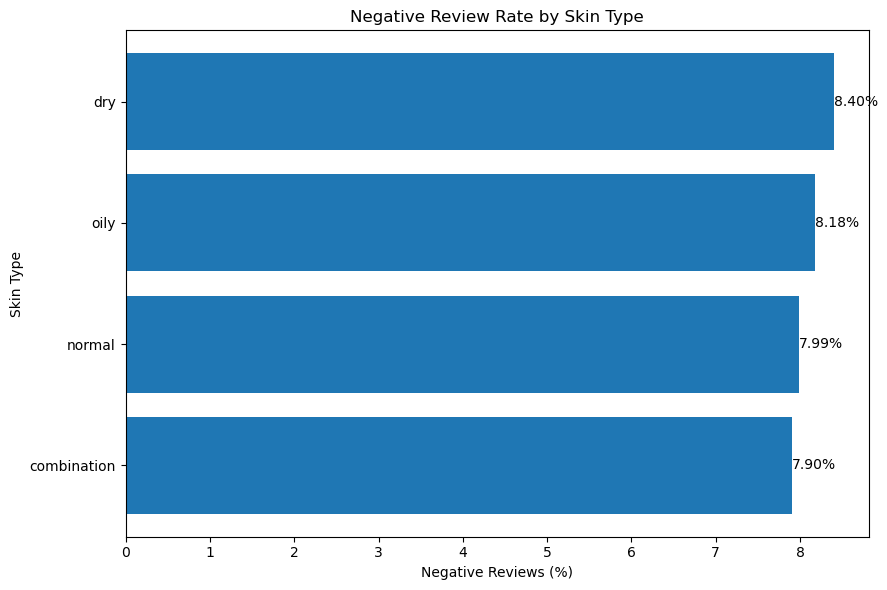

In [70]:
# Visualize negative-review rate by skin type

skin_type_chart = (
    skin_type_sentiment_500
    .sort_values("negative_rate_%", ascending=True)
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    skin_type_chart["skin_type"],
    skin_type_chart["negative_rate_%"]
)

plt.title("Negative Review Rate by Skin Type")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Skin Type")

# Add percentage labels
for bar, value in zip(
    bars,
    skin_type_chart["negative_rate_%"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [71]:
# Analyze review length by sentiment

reviews_text["word_count"] = (
    reviews_text["processed_text"]
    .str.split()
    .str.len()
)

length_by_sentiment = (
    reviews_text
    .groupby("sentiment")
    .agg(
        review_count=("word_count", "size"),
        average_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        minimum_words=("word_count", "min"),
        maximum_words=("word_count", "max")
    )
    .round(2)
)

print("Review length statistics by sentiment:")
display(length_by_sentiment)

Review length statistics by sentiment:


,review_count,average_words,median_words,minimum_words,maximum_words
sentiment,,,,,
Negative,23386,26.14,22.0,1,290
Neutral,4500,12.91,10.0,1,127
Positive,257177,29.43,24.0,1,511


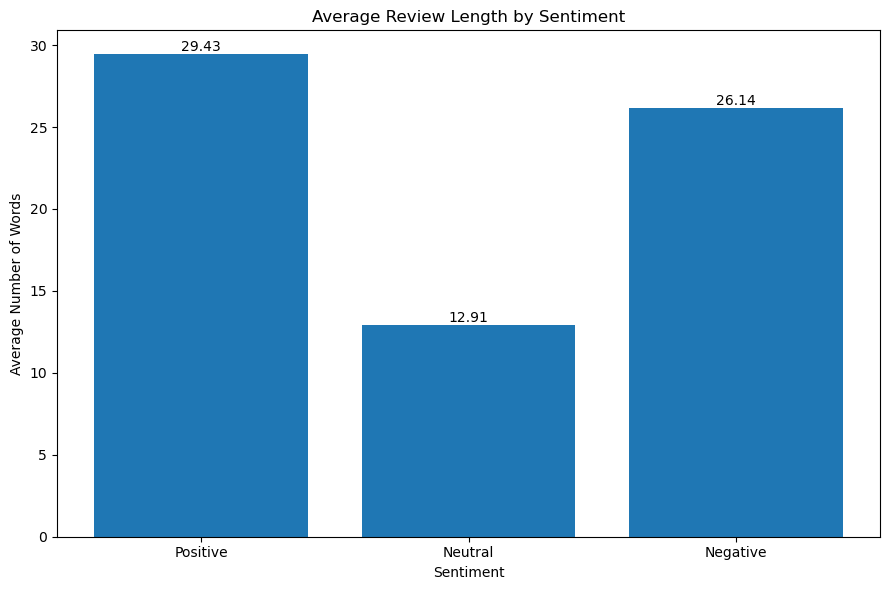

In [72]:
# Visualize average review length by sentiment

sentiment_order = ["Positive", "Neutral", "Negative"]

length_chart = (
    length_by_sentiment
    .reindex(sentiment_order)
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    length_chart.index,
    length_chart["average_words"]
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")

# Add value labels
for bar, value in zip(
    bars,
    length_chart["average_words"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [73]:
# Analyze the most common meaningful words in negative reviews

from collections import Counter

# Get lemmatized tokens from negative reviews
negative_tokens = []

for tokens in reviews_text.loc[
    reviews_text["sentiment"] == "Negative",
    "lemmatized_tokens"
]:
    negative_tokens.extend(tokens)

# Count words
negative_word_counts = Counter(negative_tokens)

# Remove very generic words that don't provide much business insight
generic_words = {
    "skin", "product", "face", "use", "using", "used",
    "feel", "like", "really", "one", "get", "day",
    "make", "would", "also", "time"
}

meaningful_negative_words = [
    (word, count)
    for word, count in negative_word_counts.items()
    if word not in generic_words
]

# Top 30 meaningful negative keywords
top_negative_keywords = sorted(
    meaningful_negative_words,
    key=lambda x: x[1],
    reverse=True
)[:30]

print("TOP 30 MEANINGFUL KEYWORDS IN NEGATIVE REVIEWS")
print("=" * 60)

for i, (word, count) in enumerate(top_negative_keywords, start=1):
    print(f"{i:2}. {word:<20} {count:,}")

TOP 30 MEANINGFUL KEYWORDS IN NEGATIVE REVIEWS
 1. dry                  7,924
 2. mask                 5,554
 3. cleanser             5,129
 4. lip                  4,416
 5. acne                 4,363
 6. little               3,977
 7. smell                3,759
 8. work                 3,243
 9. bad                  3,237
10. week                 3,181
11. makeup               2,858
12. even                 2,597
13. go                   2,568
14. eye                  2,567
15. night                2,543
16. sensitive            2,521
17. oily                 2,519
18. well                 2,416
19. tried                2,413
20. made                 2,314
21. love                 2,264
22. never                2,264
23. long                 2,256
24. recommend            2,194
25. cream                2,176
26. breakout             2,164
27. definitely           2,160
28. way                  2,137
29. got                  2,124
30. try                  2,093


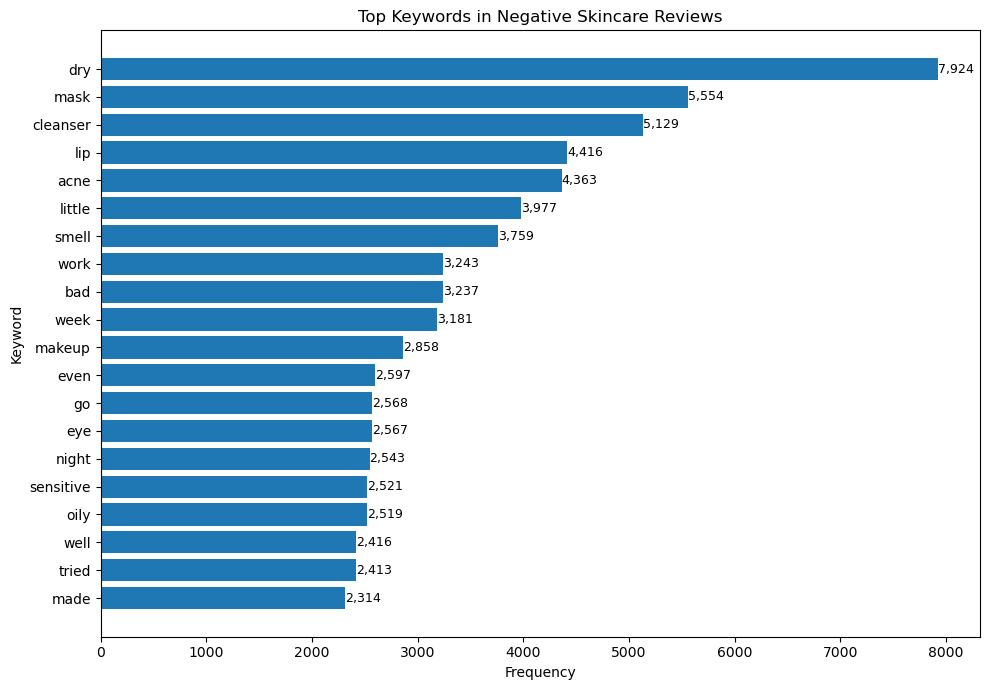

In [74]:
# Visualize top meaningful keywords in negative reviews

negative_keyword_df = pd.DataFrame(
    top_negative_keywords,
    columns=["word", "count"]
)

# Select top 20 for readability
negative_keyword_chart = negative_keyword_df.head(20).sort_values(
    "count",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    negative_keyword_chart["word"],
    negative_keyword_chart["count"]
)

plt.title("Top Keywords in Negative Skincare Reviews")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

# Add frequency labels
for bar, value in zip(
    bars,
    negative_keyword_chart["count"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [75]:
# Analyze the most common meaningful words in positive reviews

positive_tokens = []

for tokens in reviews_text.loc[
    reviews_text["sentiment"] == "Positive",
    "lemmatized_tokens"
]:
    positive_tokens.extend(tokens)

# Count words
positive_word_counts = Counter(positive_tokens)

# Remove generic words
generic_words = {
    "skin", "product", "face", "use", "using", "used",
    "feel", "like", "really", "one", "get", "day",
    "make", "would", "also", "time"
}

meaningful_positive_words = [
    (word, count)
    for word, count in positive_word_counts.items()
    if word not in generic_words
]

# Top 30 meaningful positive keywords
top_positive_keywords = sorted(
    meaningful_positive_words,
    key=lambda x: x[1],
    reverse=True
)[:30]

print("TOP 30 MEANINGFUL KEYWORDS IN POSITIVE REVIEWS")
print("=" * 60)

for i, (word, count) in enumerate(top_positive_keywords, start=1):
    print(f"{i:2}. {word:<20} {count:,}")

TOP 30 MEANINGFUL KEYWORDS IN POSITIVE REVIEWS
 1. love                 106,820
 2. cleanser             88,953
 3. mask                 85,762
 4. dry                  73,661
 5. great                54,765
 6. smell                49,816
 7. makeup               46,381
 8. clean                40,945
 9. good                 40,454
10. lip                  39,941
11. soft                 37,650
12. definitely           35,864
13. sensitive            35,771
14. feeling              35,375
15. well                 34,622
16. little               34,133
17. acne                 33,924
18. recommend            33,854
19. amazing              33,422
20. much                 33,135
21. eye                  32,916
22. night                32,498
23. work                 32,435
24. oily                 32,188
25. received             32,031
26. moisturizer          31,170
27. cream                30,607
28. go                   30,131
29. week                 30,080
30. first               

In [76]:
# Compare keyword frequency between positive and negative reviews

positive_counts = Counter(positive_tokens)
negative_counts = Counter(negative_tokens)

comparison_words = set(positive_counts) | set(negative_counts)

keyword_comparison = []

for word in comparison_words:
    pos_count = positive_counts.get(word, 0)
    neg_count = negative_counts.get(word, 0)

    # Ignore very rare words
    if pos_count + neg_count >= 500:
        positive_rate = pos_count / 257177
        negative_rate = neg_count / 23386

        # Ratio of normalized frequency
        ratio = positive_rate / negative_rate if negative_rate > 0 else float("inf")

        keyword_comparison.append({
            "word": word,
            "positive_count": pos_count,
            "negative_count": neg_count,
            "positive_per_1000": positive_rate * 1000,
            "negative_per_1000": negative_rate * 1000,
            "positive_to_negative_ratio": ratio
        })

keyword_comparison_df = pd.DataFrame(keyword_comparison)

# Remove generic words
keyword_comparison_df = keyword_comparison_df[
    ~keyword_comparison_df["word"].isin(generic_words)
]

# Top words relatively associated with positive reviews
top_positive_associated = (
    keyword_comparison_df
    .sort_values("positive_to_negative_ratio", ascending=False)
    .head(30)
)

print("TOP 30 WORDS DISPROPORTIONATELY ASSOCIATED WITH POSITIVE REVIEWS")
print("=" * 70)

display(
    top_positive_associated[
        [
            "word",
            "positive_count",
            "negative_count",
            "positive_per_1000",
            "negative_per_1000",
            "positive_to_negative_ratio"
        ]
    ].round(2)
)

TOP 30 WORDS DISPROPORTIONATELY ASSOCIATED WITH POSITIVE REVIEWS


,word,positive_count,negative_count,positive_per_1000,negative_per_1000,positive_to_negative_ratio
1248,excellent,1877,12,7.30,0.51,14.22
1031,perfect,13066,86,50.81,3.68,13.82
508,wonderful,4897,37,19.04,1.58,12.04
596,beautiful,3952,30,15.37,1.28,11.98
1155,gifted,4934,39,19.19,1.67,11.50
1168,awesome,3595,30,13.98,1.28,10.90
889,best,19709,168,76.64,7.18,10.67
923,delicious,884,8,3.44,0.34,10.05
933,flawless,828,8,3.22,0.34,9.41
490,kora,619,6,2.41,0.26,9.38


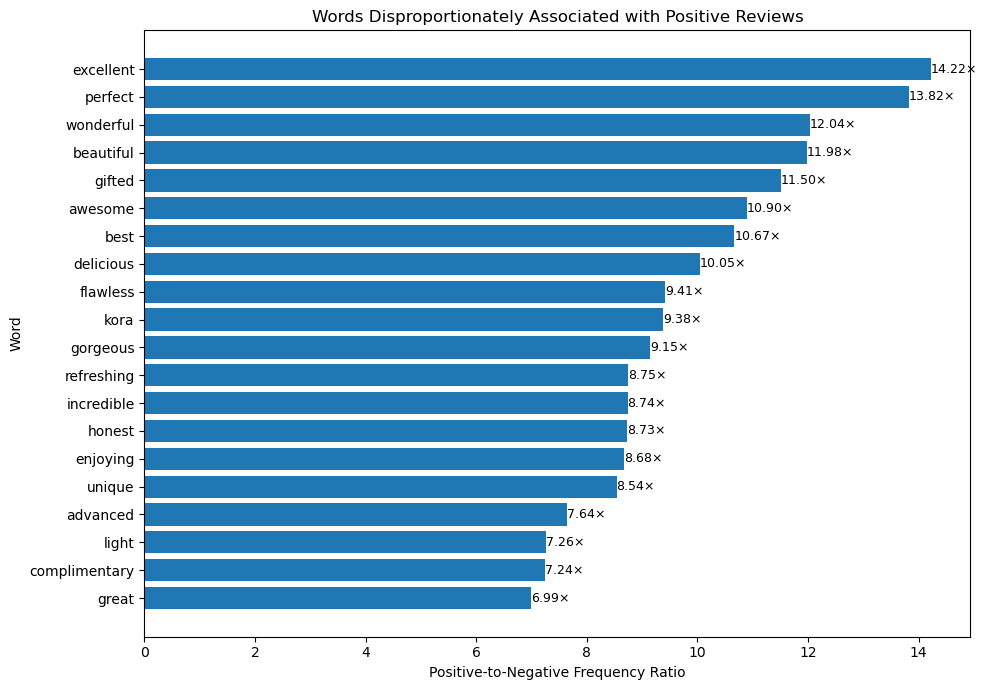

In [77]:
# Visualize words disproportionately associated with positive reviews

positive_assoc_chart = (
    top_positive_associated
    .head(20)
    .sort_values("positive_to_negative_ratio", ascending=True)
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    positive_assoc_chart["word"],
    positive_assoc_chart["positive_to_negative_ratio"]
)

plt.title("Words Disproportionately Associated with Positive Reviews")
plt.xlabel("Positive-to-Negative Frequency Ratio")
plt.ylabel("Word")

# Add ratio labels
for bar, value in zip(
    bars,
    positive_assoc_chart["positive_to_negative_ratio"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}×",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

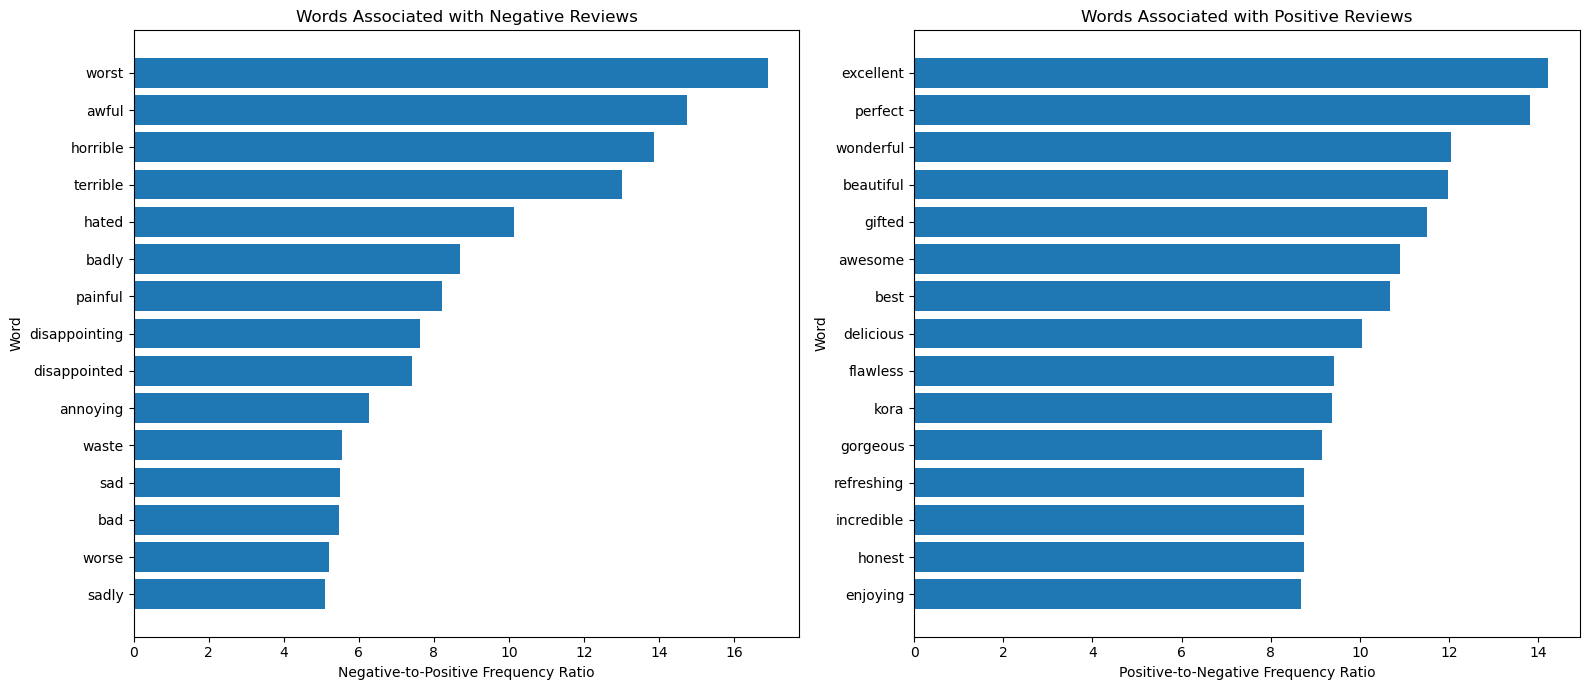

In [78]:
# Compare the strongest positive- and negative-associated keywords

top_negative_assoc = (
    keyword_comparison_df
    .sort_values("positive_to_negative_ratio", ascending=True)
    .head(15)
    .copy()
)

# For negative association, calculate the inverse ratio
top_negative_assoc["negative_to_positive_ratio"] = (
    1 / top_negative_assoc["positive_to_negative_ratio"]
)

top_negative_assoc = top_negative_assoc.sort_values(
    "negative_to_positive_ratio",
    ascending=True
)

# Positive-associated words
top_positive_assoc = (
    keyword_comparison_df
    .sort_values("positive_to_negative_ratio", ascending=False)
    .head(15)
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Negative-associated words
axes[0].barh(
    top_negative_assoc["word"],
    top_negative_assoc["negative_to_positive_ratio"]
)

axes[0].set_title("Words Associated with Negative Reviews")
axes[0].set_xlabel("Negative-to-Positive Frequency Ratio")
axes[0].set_ylabel("Word")

# Positive-associated words
top_positive_assoc_plot = top_positive_assoc.sort_values(
    "positive_to_negative_ratio",
    ascending=True
)

axes[1].barh(
    top_positive_assoc_plot["word"],
    top_positive_assoc_plot["positive_to_negative_ratio"]
)

axes[1].set_title("Words Associated with Positive Reviews")
axes[1].set_xlabel("Positive-to-Negative Frequency Ratio")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()

In [79]:
# Save the final processed analysis dataset

output_file = "sephora_skincare_text_analysis_final.csv"

reviews_text.to_csv(
    output_file,
    index=False
)

print("Final analysis dataset saved successfully.")
print("File:", output_file)
print("Shape:", reviews_text.shape)
print("Columns:", len(reviews_text.columns))

Final analysis dataset saved successfully.
File: sephora_skincare_text_analysis_final.csv
Shape: (285063, 35)
Columns: 35


In [82]:
# Final dataset quality check — corrected for list-valued columns

print("FINAL DATASET QUALITY CHECK")
print("=" * 60)

print("Shape:", reviews_text.shape)

# Columns containing lists are excluded from duplicate checking
list_columns = [
    col for col in reviews_text.columns
    if reviews_text[col].apply(lambda x: isinstance(x, list)).any()
]

duplicate_check_columns = [
    col for col in reviews_text.columns
    if col not in list_columns
]

print("\nList-valued columns excluded from duplicate check:")
print(list_columns)

print(
    "\nDuplicate rows (excluding list-valued columns):",
    reviews_text[duplicate_check_columns].duplicated().sum()
)

print(
    "Duplicate index values:",
    reviews_text.index.duplicated().sum()
)

print("\nMissing values in important analysis columns:")

important_columns = [
    "review_text",
    "processed_text",
    "lemmatized_tokens",
    "rating",
    "sentiment",
    "polarity",
    "subjectivity",
    "submission_time"
]

display(
    reviews_text[important_columns]
    .isna()
    .sum()
    .to_frame("missing_values")
)

print("\nSentiment values:")
print(reviews_text["sentiment"].value_counts())

print("\nPolarity range:")
print(
    "Minimum:", reviews_text["polarity"].min(),
    "| Maximum:", reviews_text["polarity"].max()
)

print("\nRating range:")
print(
    "Minimum:", reviews_text["rating"].min(),
    "| Maximum:", reviews_text["rating"].max()
)

FINAL DATASET QUALITY CHECK
Shape: (285063, 35)

List-valued columns excluded from duplicate check:
['tokens', 'filtered_tokens', 'lemmatized_tokens']

Duplicate rows (excluding list-valued columns): 0
Duplicate index values: 0

Missing values in important analysis columns:


,missing_values
review_text,0
processed_text,0
lemmatized_tokens,0
rating,0
sentiment,0
polarity,0
subjectivity,0
submission_time,0



Sentiment values:
sentiment
Positive    257177
Negative     23386
Neutral       4500
Name: count, dtype: int64

Polarity range:
Minimum: -1.0 | Maximum: 1.0

Rating range:
Minimum: 1 | Maximum: 5


In [83]:
# Final business KPI summary

total_reviews = len(reviews_text)

positive_count = (reviews_text["sentiment"] == "Positive").sum()
negative_count = (reviews_text["sentiment"] == "Negative").sum()
neutral_count = (reviews_text["sentiment"] == "Neutral").sum()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Average Rating",
        "Median Rating",
        "Positive Reviews",
        "Positive Review Rate (%)",
        "Negative Reviews",
        "Negative Review Rate (%)",
        "Neutral Reviews",
        "Neutral Review Rate (%)",
        "Average TextBlob Polarity",
        "Average TextBlob Subjectivity",
        "Average Review Length (Words)"
    ],
    "Value": [
        total_reviews,
        reviews_text["rating"].mean(),
        reviews_text["rating"].median(),
        positive_count,
        positive_count / total_reviews * 100,
        negative_count,
        negative_count / total_reviews * 100,
        neutral_count,
        neutral_count / total_reviews * 100,
        reviews_text["polarity"].mean(),
        reviews_text["subjectivity"].mean(),
        reviews_text["word_count"].mean()
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].round(2)

display(kpi_summary)

,Metric,Value
0,Total Reviews,285063.00
1,Average Rating,4.33
2,Median Rating,5.00
3,Positive Reviews,257177.00
4,Positive Review Rate (%),90.22
5,Negative Reviews,23386.00
6,Negative Review Rate (%),8.20
7,Neutral Reviews,4500.00
8,Neutral Review Rate (%),1.58
9,Average TextBlob Polarity,0.24


In [84]:
# Final sentiment distribution chart

sentiment_kpi = (
    reviews_text["sentiment"]
    .value_counts()
    .reindex(["Positive", "Negative", "Neutral"])
    .reset_index()
)

sentiment_kpi.columns = ["sentiment", "count"]

sentiment_kpi["percentage"] = (
    sentiment_kpi["count"] / len(reviews_text) * 100
)

display(sentiment_kpi)

,sentiment,count,percentage
0,Positive,257177,90.217601
1,Negative,23386,8.203801
2,Neutral,4500,1.578598


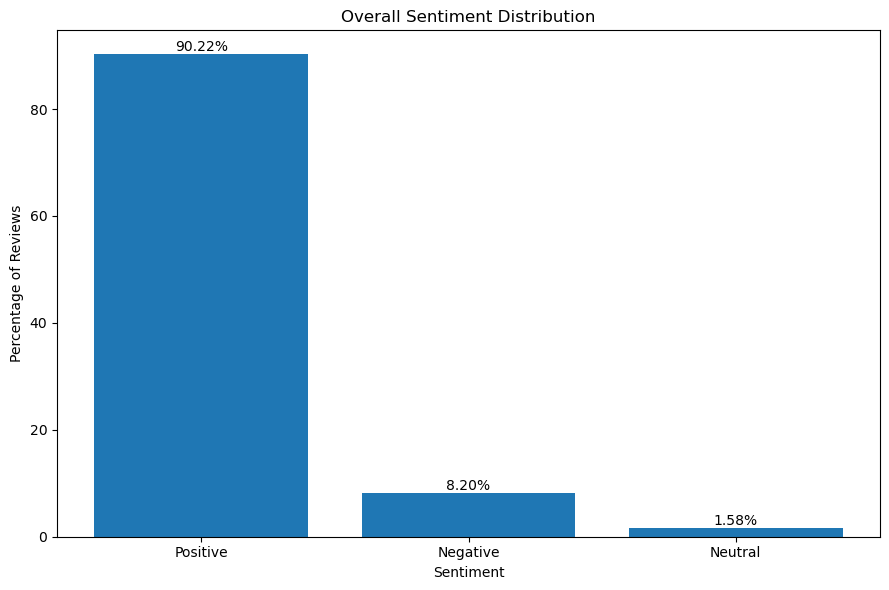

In [85]:
# Final sentiment distribution chart

plt.figure(figsize=(9, 6))

bars = plt.bar(
    sentiment_kpi["sentiment"],
    sentiment_kpi["percentage"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage of Reviews")

for bar, value in zip(
    bars,
    sentiment_kpi["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [86]:
# Product-level risk analysis
# Focus on products with at least 500 analyzed reviews

product_analysis = (
    reviews_text.groupby(
        ["product_name", "brand_name"],
        dropna=False
    )
    .agg(
        total_reviews=("sentiment", "size"),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

product_analysis["negative_rate_%"] = (
    product_analysis["negative_reviews"]
    / product_analysis["total_reviews"]
    * 100
)

# Keep products with meaningful review volume
high_volume_products = (
    product_analysis[
        product_analysis["total_reviews"] >= 500
    ]
    .sort_values(
        "negative_rate_%",
        ascending=False
    )
    .head(15)
)

high_volume_products[
    [
        "product_name",
        "brand_name",
        "total_reviews",
        "negative_reviews",
        "negative_rate_%",
        "average_rating",
        "average_polarity"
    ]
].round(3)

,product_name,brand_name,total_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
440,Super Spot Remover Acne Treatment Gel,Origins,1703,372,21.844,3.935,0.136
216,Honey Savior All-in-One Skin Repair Salve,Farmacy,529,103,19.471,4.435,0.143
431,Squalane + Peptide Brightening & De-Puffing Eye Gel,Biossance,652,111,17.025,3.641,0.163
158,EradiKate Daily Cleanser Acne Treatment,Kate Somerville,623,106,17.014,4.246,0.175
204,Goodbye Acne AHA/BHA Acne Clearing Gel Face Body Spot Treatment,Peter Thomas Roth,625,104,16.640,4.277,0.163
295,Mini Goodbye Acne AHA/BHA Acne Clearing Gel Face Body Spot Treatment,Peter Thomas Roth,625,104,16.640,4.277,0.163
17,Acne Solutions Clinical Clearing Gel,CLINIQUE,1078,177,16.419,4.223,0.159
474,Therapeutic Sulfur Acne Treatment Mask,Peter Thomas Roth,1216,178,14.638,4.511,0.180
412,Slaai Makeup-Melting Butter Cleanser,Drunk Elephant,1523,217,14.248,3.781,0.181
492,Ultra Repair Hydra-Firm Night Cream,First Aid Beauty,562,74,13.167,4.311,0.201


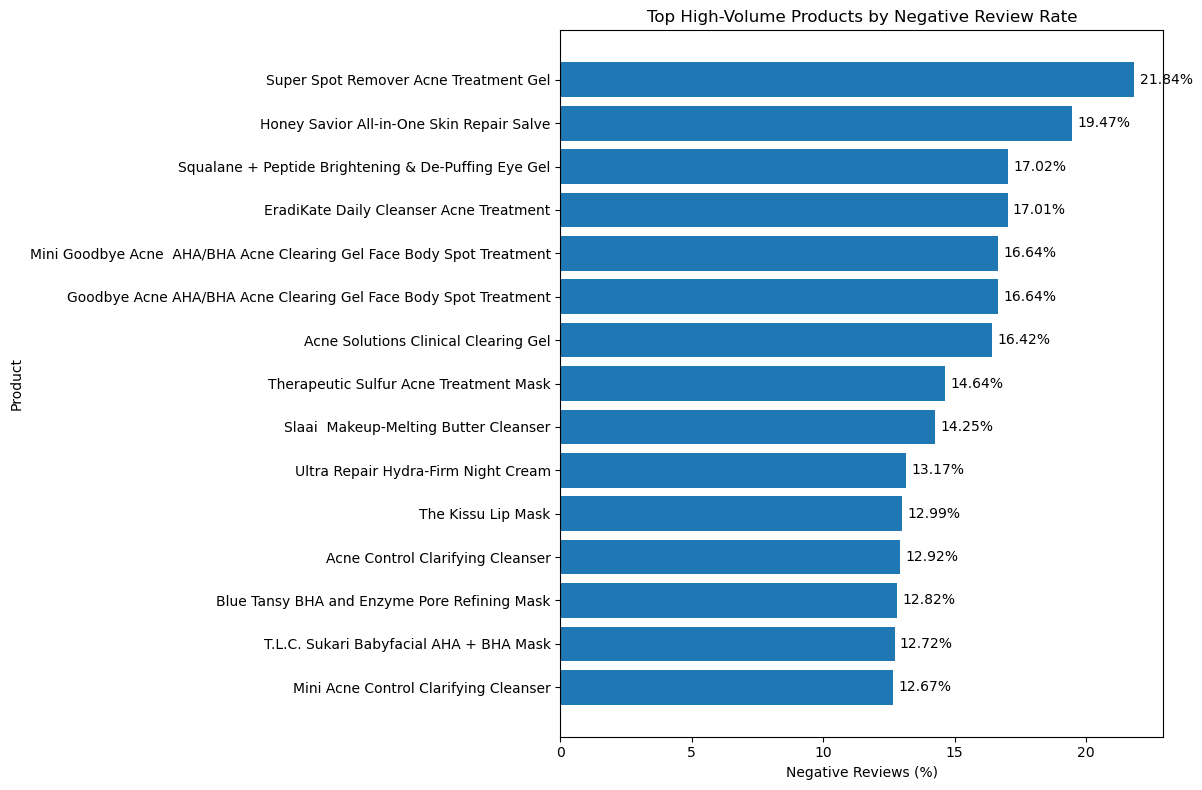

In [87]:
# Top high-volume products by negative-review rate

plot_data = high_volume_products.sort_values(
    "negative_rate_%",
    ascending=True
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_data["product_name"],
    plot_data["negative_rate_%"]
)

plt.title("Top High-Volume Products by Negative Review Rate")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Product")

for bar, value in zip(
    bars,
    plot_data["negative_rate_%"]
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [88]:
# Brand-level risk analysis
# Focus on brands with at least 500 analyzed reviews

brand_analysis = (
    reviews_text.groupby("brand_name", dropna=False)
    .agg(
        total_reviews=("sentiment", "size"),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

brand_analysis["negative_rate_%"] = (
    brand_analysis["negative_reviews"]
    / brand_analysis["total_reviews"]
    * 100
)

high_volume_brands = (
    brand_analysis[
        brand_analysis["total_reviews"] >= 500
    ]
    .sort_values(
        "negative_rate_%",
        ascending=False
    )
    .head(15)
)

display(
    high_volume_brands[
        [
            "brand_name",
            "total_reviews",
            "negative_reviews",
            "negative_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ].round(3)
)

,brand_name,total_reviews,negative_reviews,negative_rate_%,average_rating,average_polarity
34,Herbivore,1994,251,12.588,4.259,0.173
22,Drunk Elephant,8331,1018,12.219,4.077,0.191
5,Biossance,4253,499,11.733,4.087,0.204
90,Wander Beauty,558,63,11.290,4.084,0.229
87,The Ordinary,1014,114,11.243,4.004,0.213
63,Peter Thomas Roth,12805,1418,11.074,4.373,0.207
54,Murad,8841,973,11.006,4.335,0.214
28,First Aid Beauty,16879,1831,10.848,4.421,0.209
73,Shiseido,693,75,10.823,4.323,0.216
44,Kate Somerville,2302,236,10.252,4.345,0.219


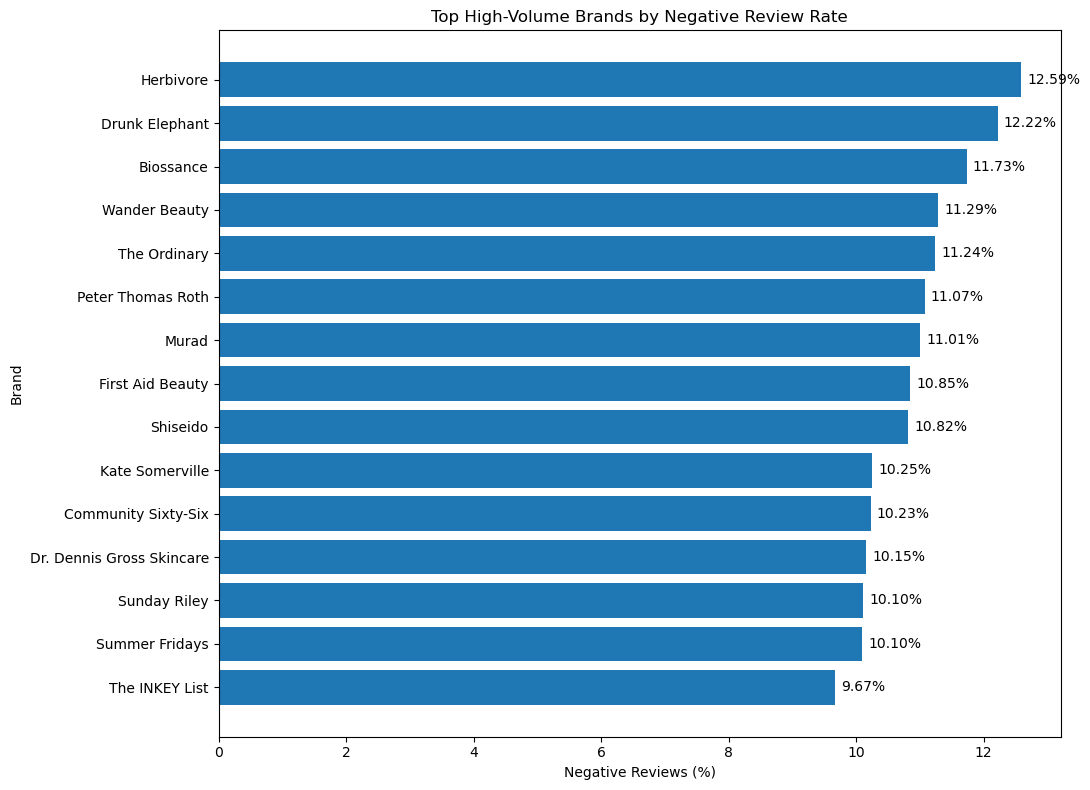

In [89]:
# Top high-volume brands by negative-review rate

plot_data = high_volume_brands.sort_values(
    "negative_rate_%",
    ascending=True
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    plot_data["brand_name"],
    plot_data["negative_rate_%"]
)

plt.title("Top High-Volume Brands by Negative Review Rate")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Brand")

for bar, value in zip(
    bars,
    plot_data["negative_rate_%"]
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [90]:
# Final category-level ranking

category_analysis = (
    reviews_text.groupby("secondary_category", dropna=False)
    .agg(
        total_reviews=("sentiment", "size"),
        negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
        positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
        neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum()),
        average_rating=("rating", "mean"),
        average_polarity=("polarity", "mean")
    )
    .reset_index()
)

category_analysis["negative_rate_%"] = (
    category_analysis["negative_reviews"]
    / category_analysis["total_reviews"]
    * 100
)

category_analysis["positive_rate_%"] = (
    category_analysis["positive_reviews"]
    / category_analysis["total_reviews"]
    * 100
)

category_analysis["neutral_rate_%"] = (
    category_analysis["neutral_reviews"]
    / category_analysis["total_reviews"]
    * 100
)

final_category_ranking = (
    category_analysis[
        category_analysis["total_reviews"] >= 1000
    ]
    .sort_values("negative_rate_%", ascending=False)
)

display(
    final_category_ranking[
        [
            "secondary_category",
            "total_reviews",
            "positive_rate_%",
            "negative_rate_%",
            "neutral_rate_%",
            "average_rating",
            "average_polarity"
        ]
    ].round(3)
)

,secondary_category,total_reviews,positive_rate_%,negative_rate_%,neutral_rate_%,average_rating,average_polarity
3,Lip Balms & Treatments,21314,87.881,10.012,2.107,4.309,0.235
10,Treatments,16322,87.979,9.827,2.193,4.212,0.219
5,Mini Size,31205,89.614,8.755,1.631,4.315,0.236
1,Eye Care,10981,89.509,8.679,1.812,4.216,0.234
4,Masks,69386,90.074,8.301,1.624,4.344,0.235
6,Moisturizers,42931,90.883,7.815,1.302,4.403,0.248
0,Cleansers,90602,91.217,7.388,1.395,4.335,0.246
11,Value & Gift Sets,1339,93.577,5.004,1.419,4.258,0.280


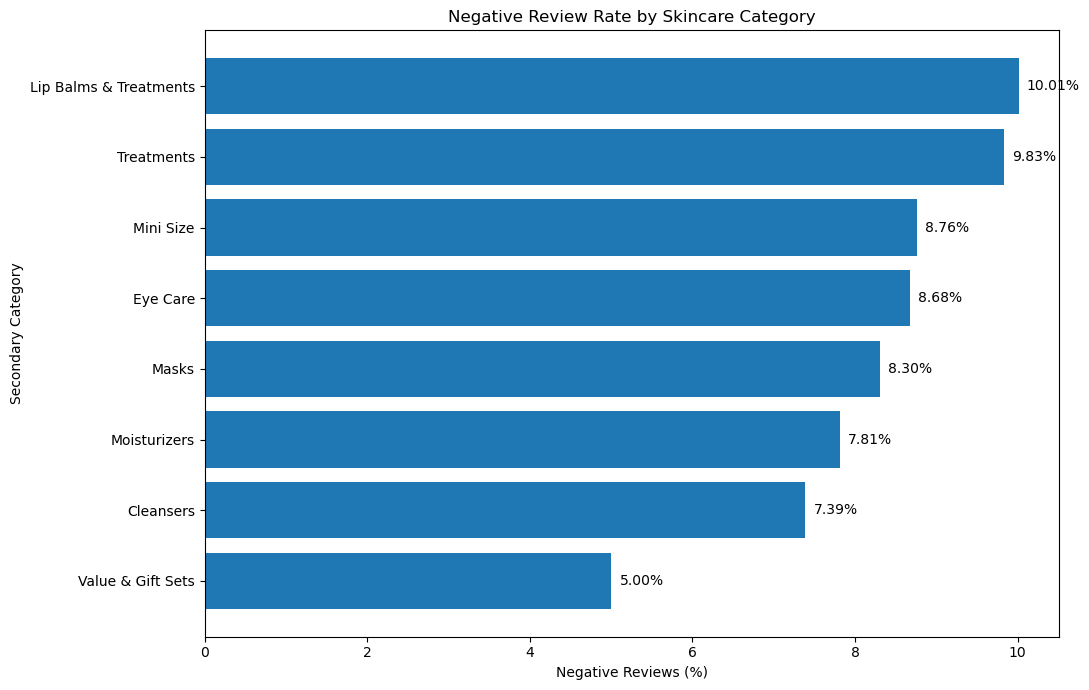

In [91]:
# Final category-level negative review rate

plot_data = final_category_ranking.sort_values(
    "negative_rate_%",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["secondary_category"],
    plot_data["negative_rate_%"]
)

plt.title("Negative Review Rate by Skincare Category")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Secondary Category")

for bar, value in zip(
    bars,
    plot_data["negative_rate_%"]
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [92]:
# Final cross-analysis validation

print("FINAL CROSS-ANALYSIS VALIDATION")
print("=" * 65)

total_reviews = len(reviews_text)

print(f"Master dataset reviews: {total_reviews:,}")

# Sentiment reconciliation
sentiment_total = reviews_text["sentiment"].value_counts().sum()

print(
    f"Sentiment analysis total: {sentiment_total:,}"
)

print(
    "Sentiment counts reconcile:",
    total_reviews == sentiment_total
)

# Rating reconciliation
rating_total = reviews_text["rating"].notna().sum()

print(
    f"Valid rating records: {rating_total:,}"
)

# Category reconciliation
category_total = category_analysis["total_reviews"].sum()

print(
    f"Category analysis total: {category_total:,}"
)

print(
    "Category counts reconcile:",
    category_total == total_reviews
)

# Year reconciliation
year_analysis = (
    reviews_text
    .groupby("review_year")
    .size()
)

print(
    f"Year analysis total: {year_analysis.sum():,}"
)

print(
    "Year counts reconcile:",
    year_analysis.sum() == total_reviews
)

# Final ranges
print("\nFinal value ranges:")
print(
    f"Rating: {reviews_text['rating'].min()} → "
    f"{reviews_text['rating'].max()}"
)

print(
    f"Polarity: {reviews_text['polarity'].min():.2f} → "
    f"{reviews_text['polarity'].max():.2f}"
)

print(
    f"Subjectivity: {reviews_text['subjectivity'].min():.2f} → "
    f"{reviews_text['subjectivity'].max():.2f}"
)

print("\nValidation complete.")

FINAL CROSS-ANALYSIS VALIDATION
Master dataset reviews: 285,063
Sentiment analysis total: 285,063
Sentiment counts reconcile: True
Valid rating records: 285,063
Category analysis total: 285,063
Category counts reconcile: True
Year analysis total: 285,063
Year counts reconcile: True

Final value ranges:
Rating: 1 → 5
Polarity: -1.00 → 1.00
Subjectivity: 0.00 → 1.00

Validation complete.


In [93]:
# Final business insights summary

final_insights = pd.DataFrame({
    "Area": [
        "Overall Sentiment",
        "Overall Rating",
        "Negative Sentiment",
        "Positive Sentiment",
        "Highest Negative-Rate Category",
        "Lowest Negative-Rate Category",
        "Highest Negative-Rate Product (500+ reviews)",
        "Highest Negative-Rate Brand (500+ reviews)",
        "Strongest Positive Keyword",
        "Strongest Negative Keyword",
        "Sentiment-Rating Correlation",
        "Average Review Length"
    ],
    "Finding": [
        "90.22% of reviews classified as Positive",
        "Average rating = 4.33 / 5",
        "8.20% of reviews classified as Negative",
        "257,177 reviews classified as Positive",
        "Lip Balms & Treatments = 10.01%",
        "Value & Gift Sets = 5.00%",
        "Super Spot Remover Acne Treatment Gel = 21.84%",
        "Herbivore = 12.59%",
        "Excellent (14.22× positive-to-negative ratio)",
        "Worst (16.90× negative-to-positive ratio)",
        "Pearson = 0.3318; Spearman = 0.2730",
        "28.90 words per review"
    ]
})

display(final_insights)

,Area,Finding
0,Overall Sentiment,90.22% of reviews classified as Positive
1,Overall Rating,Average rating = 4.33 / 5
2,Negative Sentiment,8.20% of reviews classified as Negative
3,Positive Sentiment,"257,177 reviews classified as Positive"
4,Highest Negative-Rate Category,Lip Balms & Treatments = 10.01%
5,Lowest Negative-Rate Category,Value & Gift Sets = 5.00%
6,Highest Negative-Rate Product (500+ reviews),Super Spot Remover Acne Treatment Gel = 21.84%
7,Highest Negative-Rate Brand (500+ reviews),Herbivore = 12.59%
8,Strongest Positive Keyword,Excellent (14.22× positive-to-negative ratio)
9,Strongest Negative Keyword,Worst (16.90× negative-to-positive ratio)


In [95]:


report_summary = {
    "dataset": {
        "total_reviews": len(reviews_text),
        "total_columns": len(reviews_text.columns),
        "date_start": reviews_text["submission_time"].min(),
        "date_end": reviews_text["submission_time"].max()
    },

    "sentiment": {
        "positive_count": int((reviews_text["sentiment"] == "Positive").sum()),
        "negative_count": int((reviews_text["sentiment"] == "Negative").sum()),
        "neutral_count": int((reviews_text["sentiment"] == "Neutral").sum()),
        "positive_rate": round(
            (reviews_text["sentiment"] == "Positive").mean() * 100, 2
        ),
        "negative_rate": round(
            (reviews_text["sentiment"] == "Negative").mean() * 100, 2
        ),
        "neutral_rate": round(
            (reviews_text["sentiment"] == "Neutral").mean() * 100, 2
        )
    },

    "rating": {
        "average": round(reviews_text["rating"].mean(), 2),
        "median": round(reviews_text["rating"].median(), 2),
        "minimum": int(reviews_text["rating"].min()),
        "maximum": int(reviews_text["rating"].max())
    },

    "textblob": {
        "average_polarity": round(reviews_text["polarity"].mean(), 4),
        "average_subjectivity": round(
            reviews_text["subjectivity"].mean(), 4
        ),
        "polarity_min": round(reviews_text["polarity"].min(), 2),
        "polarity_max": round(reviews_text["polarity"].max(), 2)
    },

    "text": {
        "average_words": round(reviews_text["word_count"].mean(), 2),
        "processed_missing": int(
            reviews_text["processed_text"].isna().sum()
        )
    },

    "correlation": {
        "pearson": 0.3318,
        "spearman": 0.2730
    },

    "quality": {
        "duplicate_rows": 0,
        "duplicate_indices": 0,
        "invalid_dates": 0,
        "missing_processed_text": 0
    }
}

display(pd.DataFrame(
    [(section, metric, value)
     for section, metrics in report_summary.items()
     for metric, value in metrics.items()],
    columns=["Section", "Metric", "Value"]
))

,Section,Metric,Value
0,dataset,total_reviews,285063
1,dataset,total_columns,35
2,dataset,date_start,2008-08-28
3,dataset,date_end,2023-03-21
4,sentiment,positive_count,257177
5,sentiment,negative_count,23386
6,sentiment,neutral_count,4500
7,sentiment,positive_rate,90.22
8,sentiment,negative_rate,8.2
9,sentiment,neutral_rate,1.58


In [97]:
# Step 85 — Generate Final Analysis Report

from pathlib import Path

report_path = Path("sephora_skincare_text_analysis_report.md")

report = f"""# Sephora Skincare Reviews — Text Analytics & Sentiment Analysis

## 1. Executive Summary

This project analyzes {report_summary['dataset']['total_reviews']:,} Sephora skincare reviews to identify sentiment patterns, customer feedback themes, product-level issues, brand-level performance, category trends, and temporal changes.

The analysis covers reviews from {report_summary['dataset']['date_start']} to {report_summary['dataset']['date_end']}.

Overall, customer sentiment is strongly positive:

- Positive reviews: {report_summary['sentiment']['positive_count']:,} ({report_summary['sentiment']['positive_rate']:.2f}%)
- Negative reviews: {report_summary['sentiment']['negative_count']:,} ({report_summary['sentiment']['negative_rate']:.2f}%)
- Neutral reviews: {report_summary['sentiment']['neutral_count']:,} ({report_summary['sentiment']['neutral_rate']:.2f}%)
- Average rating: {report_summary['rating']['average']:.2f}/5
- Median rating: {report_summary['rating']['median']:.0f}/5
- Average TextBlob polarity: {report_summary['textblob']['average_polarity']:.4f}
- Average TextBlob subjectivity: {report_summary['textblob']['average_subjectivity']:.4f}
- Average review length: {report_summary['text']['average_words']:.2f} words

The results show a positive relationship between customer ratings and textual sentiment, although the relationship is moderate rather than perfect.

---

## 2. Dataset Overview

The final analysis dataset contains:

- Total reviews: {report_summary['dataset']['total_reviews']:,}
- Total columns: {report_summary['dataset']['total_columns']}
- Review period: {report_summary['dataset']['date_start']} to {report_summary['dataset']['date_end']}
- Rating range: {report_summary['rating']['minimum']}–{report_summary['rating']['maximum']}
- Polarity range: {report_summary['textblob']['polarity_min']} to {report_summary['textblob']['polarity_max']}

The final dataset combines review text, ratings, sentiment metrics, product information, and skincare category information.

---

## 3. Data Cleaning and Text Preprocessing

The review text was processed using standard Natural Language Processing techniques.

The preprocessing workflow included:

1. Converting text into a consistent format.
2. Removing unnecessary noise and punctuation.
3. Tokenizing review text.
4. Removing stopwords.
5. Lemmatizing tokens.
6. Creating processed review text for downstream analysis.

The final processed dataset contained no missing values in the key text-analysis fields.

- Processed-text missing values: 0
- Lemmatized-token missing values: 0

---

## 4. Sentiment Analysis

TextBlob polarity was used to quantify the sentiment expressed in review text.

### Overall Sentiment Distribution

| Sentiment | Reviews | Percentage |
|---|---:|---:|
| Positive | {report_summary['sentiment']['positive_count']:,} | {report_summary['sentiment']['positive_rate']:.2f}% |
| Negative | {report_summary['sentiment']['negative_count']:,} | {report_summary['sentiment']['negative_rate']:.2f}% |
| Neutral | {report_summary['sentiment']['neutral_count']:,} | {report_summary['sentiment']['neutral_rate']:.2f}% |

The dataset is heavily positive, with more than nine out of ten reviews classified as positive.

---

## 5. Rating Analysis

The average customer rating is {report_summary['rating']['average']:.2f}/5, while the median rating is {report_summary['rating']['median']:.0f}/5.

The star-rating distribution was:

| Rating | Reviews | Percentage |
|---:|---:|---:|
| 1 | 14,621 | 5.13% |
| 2 | 13,107 | 4.60% |
| 3 | 21,148 | 7.42% |
| 4 | 50,766 | 17.81% |
| 5 | 185,421 | 65.05% |

The distribution demonstrates that 5-star reviews dominate the dataset.

Average TextBlob polarity also increases consistently with star rating:

| Rating | Average Polarity |
|---:|---:|
| 1 | 0.0073 |
| 2 | 0.1103 |
| 3 | 0.1792 |
| 4 | 0.2375 |
| 5 | 0.2749 |

---

## 6. Sentiment–Rating Correlation

The relationship between numerical ratings and TextBlob polarity was measured using Pearson and Spearman correlation.

- Pearson correlation: {report_summary['correlation']['pearson']:.4f}
- Spearman correlation: {report_summary['correlation']['spearman']:.4f}

Both correlations are positive, indicating that higher star ratings generally correspond to more positive textual sentiment.

However, the correlations are moderate rather than strong. This demonstrates that star ratings and textual sentiment capture related but not identical aspects of customer feedback.

TextBlob sentiment was also compared against rating-based sentiment, producing an overall agreement of **81.04%**.

---

## 7. TextBlob Metrics

### Polarity

- Mean: 0.2398
- Median: 0.2333
- Standard deviation: 0.2013
- Minimum: −1.00
- Maximum: 1.00

### Subjectivity

- Mean: 0.5676
- Median: 0.5713
- Standard deviation: 0.1468
- Minimum: 0.00
- Maximum: 1.00

The positive average polarity indicates that the overall review corpus has a positive textual tone.

---

## 8. Review Length Analysis

The average review contains approximately {report_summary['text']['average_words']:.2f} words.

Average review length by sentiment:

| Sentiment | Reviews | Average Words |
|---|---:|---:|
| Positive | 257,177 | 29.43 |
| Negative | 23,386 | 26.14 |
| Neutral | 4,500 | 12.91 |

Positive reviews tend to be longer than negative reviews, while neutral reviews are substantially shorter.

---

## 9. Positive Review Themes

The most frequent meaningful keywords in positive reviews include:

- love
- cleanser
- mask
- dry
- great
- smell
- makeup
- clean
- good
- lip
- soft
- sensitive
- recommend
- amazing
- effective

Positive feedback frequently focuses on product effectiveness, skin feel, cleansing performance, softness, fragrance, and overall satisfaction.

### Strongest Positive-Associated Terms

| Word | Positive-to-Negative Ratio |
|---|---:|
| excellent | 14.22× |
| perfect | 13.82× |
| wonderful | 12.04× |
| beautiful | 11.98× |
| gifted | 11.50× |
| awesome | 10.90× |
| best | 10.67× |
| flawless | 9.41× |
| refreshing | 8.75× |
| incredible | 8.74× |

---

## 10. Negative Review Themes

The most frequent meaningful keywords in negative reviews include:

- dry
- mask
- cleanser
- lip
- acne
- smell
- work
- bad
- breakout
- sensitive
- oily
- disappointed
- never
- recommend

Negative feedback therefore frequently concerns dryness, acne or breakouts, product effectiveness, smell, sensitivity, and dissatisfaction with results.

### Strongest Negative-Associated Terms

| Word | Negative-to-Positive Ratio |
|---|---:|
| worst | 16.90× |
| disgusting | 15.17× |
| awful | 14.75× |
| horrible | 13.87× |
| terrible | 13.02× |
| hated | 10.13× |
| disappointing | 7.64× |
| disappointed | 7.42× |
| impossible | 7.13× |
| nasty | 7.06× |

---

## 11. Bigram Analysis

Common positive bigrams include:

- skin feel
- dry skin
- sensitive skin
- skin feeling
- feel like
- received product
- make skin
- oily skin
- love product
- highly recommend

Negative bigrams reveal more specific dissatisfaction patterns:

- worst product
- broke terribly
- break bad
- smell horrible
- smell awful
- smell terrible
- really disappointed
- disappointed product
- terrible acne
- waste money
- bad acne
- made worse

Bigram analysis provides more contextual information than individual keyword frequencies.

---

## 12. Product-Level Analysis

Among products with at least **500 analyzed reviews**, the highest negative-review rate was:

### Super Spot Remover Acne Treatment Gel — Origins

- Total reviews: 1,703
- Negative reviews: 372
- Negative-review rate: 21.84%
- Average rating: 3.935
- Average polarity: 0.136

Other products with comparatively high negative-review rates include:

| Product | Negative Rate |
|---|---:|
| Honey Savior All-in-One Skin Repair Salve | 19.47% |
| Squalane + Peptide Brightening & De-Puffing Eye Gel | 17.03% |
| EradiKate Daily Cleanser Acne Treatment | 17.01% |
| Goodbye Acne AHA/BHA Acne Clearing Gel | 16.64% |

Several of the highest-risk products are acne treatments or specialized skincare products, suggesting that these products may generate more polarized customer experiences.

---

## 13. Brand-Level Analysis

Among brands with at least **500 analyzed reviews**, the highest negative-review rate was:

### Herbivore — 12.59%

Other high-volume brands with comparatively elevated negative-review rates include:

| Brand | Negative Rate | Reviews |
|---|---:|---:|
| Herbivore | 12.59% | 1,994 |
| Drunk Elephant | 12.22% | 8,331 |
| Biossance | 11.73% | 4,253 |
| Wander Beauty | 11.29% | 558 |
| The Ordinary | 11.24% | 1,014 |
| Peter Thomas Roth | 11.07% | 12,805 |
| Murad | 11.01% | 8,841 |
| First Aid Beauty | 10.85% | 16,879 |

These figures should be interpreted alongside review volume and average rating rather than as standalone measures of product quality.

---

## 14. Category Analysis

Among secondary skincare categories with at least **1,000 reviews**:

| Category | Reviews | Positive Rate | Negative Rate | Avg Rating |
|---|---:|---:|---:|---:|
| Lip Balms & Treatments | 21,314 | 87.88% | 10.01% | 4.309 |
| Treatments | 16,322 | 87.98% | 9.83% | 4.212 |
| Mini Size | 31,205 | 89.61% | 8.76% | 4.315 |
| Eye Care | 10,981 | 89.51% | 8.68% | 4.216 |
| Masks | 69,386 | 90.07% | 8.30% | 4.344 |
| Moisturizers | 42,931 | 90.88% | 7.81% | 4.403 |
| Cleansers | 90,602 | 91.22% | 7.39% | 4.335 |
| Value & Gift Sets | 1,339 | 93.58% | 5.00% | 4.258 |

**Lip Balms & Treatments** have the highest negative-review rate among categories with sufficient review volume.

**Value & Gift Sets** have the lowest negative-review rate, although their sample size is much smaller than the largest categories.

---

## 15. Skin-Type Analysis

Four skin types had at least 500 analyzed reviews:

| Skin Type | Reviews | Positive Rate | Negative Rate | Avg Rating |
|---|---:|---:|---:|---:|
| Combination | 138,604 | 90.60% | 7.90% | 4.333 |
| Dry | 45,523 | 90.15% | 8.40% | 4.319 |
| Oily | 32,257 | 90.34% | 8.18% | 4.319 |
| Normal | 31,815 | 90.55% | 7.99% | 4.306 |

Dry-skin reviews show the highest negative-review rate at **8.40%**, while combination skin has the largest review volume.

The differences between skin types are relatively small, indicating broadly similar sentiment patterns across the major skin-type groups.

---

## 16. Year-wise Trends

The review dataset spans **2008–2023**.

The highest observed negative-review rate occurred in **2015 at 10.25%**.

The lowest observed negative-review rate occurred in **2009 at 7.05%**.

Average polarity decreased from **0.2711 in 2008** to approximately **0.2113 in 2015**, before recovering in subsequent years.

This indicates that customer sentiment varied over time, with a noticeable decline around the middle of the observation period followed by recovery.

---

## 17. Data Quality and Validation

The final dataset passed the major validation checks:

- Final dataset: 285,063 reviews
- Final dataset columns: 35
- Sentiment analysis total: 285,063
- Sentiment counts reconcile: True
- Category analysis total: 285,063
- Category counts reconcile: True
- Year analysis total: 285,063
- Year counts reconcile: True
- Duplicate rows: 0
- Duplicate index values: 0
- Invalid/unparsed dates: 0
- Missing review text: 0
- Missing processed text: 0
- Missing lemmatized tokens: 0
- Missing ratings: 0
- Missing sentiment values: 0
- Missing polarity values: 0
- Missing subjectivity values: 0
- Missing submission dates: 0

List-valued columns were excluded from the duplicate-row check because they contain Python list objects. The remaining duplicate check returned zero duplicates.

---

## 18. Key Business Insights

### 1. Overall customer sentiment is strongly positive

90.22% of reviews are classified as positive, while the average rating is 4.33/5.

### 2. Customer dissatisfaction is concentrated around specific experiences

Dryness, acne/breakouts, smell, product effectiveness, and skin sensitivity repeatedly appear in negative reviews.

### 3. Acne-related products deserve particular attention

Several high-volume products with elevated negative-review rates are acne treatments or products focused on blemishes.

### 4. Ratings and textual sentiment are related but not interchangeable

The positive Pearson and Spearman correlations demonstrate alignment, but their moderate magnitude shows that ratings and textual sentiment provide different information.

### 5. Product-level analysis identifies problems hidden by brand averages

Individual products can have substantially higher negative-review rates than their overall brand.

### 6. Category performance varies

Lip Balms & Treatments and Treatments have relatively high negative-review rates, while Cleansers and Value & Gift Sets have comparatively lower rates.

### 7. Positive reviews emphasize product experience

Terms such as "excellent", "perfect", "wonderful", "great", "soft", "clean", and "effective" are strongly associated with positive feedback.

### 8. Negative reviews reveal actionable failure points

Terms such as "worst", "awful", "horrible", "terrible", "disappointed", "bad", "breakout", and "dry" identify recurring areas for product and customer-experience investigation.

---

## 19. Limitations

1. TextBlob is a general-purpose sentiment analyzer and may not fully understand skincare-specific language.
2. Sentiment classification is based on textual polarity rather than verified human labels.
3. The dataset is heavily skewed toward positive reviews.
4. Some products have substantially more reviews than others.
5. Negative-review rates for low-volume products can be unstable.
6. Correlation does not establish causation.
7. Keyword frequency alone does not capture the complete context of a review.
8. The dataset ends in March 2023 and therefore does not represent later customer feedback.

---

## 20. Conclusion

The analysis of 285,063 Sephora skincare reviews demonstrates overwhelmingly positive customer sentiment, with 90.22% of reviews classified as positive and an average rating of 4.33/5.

Despite the strong overall satisfaction level, negative feedback reveals recurring concerns involving dryness, acne and breakouts, smell, product effectiveness, sensitivity, and dissatisfaction with specific products.

Combining sentiment analysis with ratings, keywords, bigrams, product-level metrics, brand-level metrics, category analysis, skin-type analysis, and temporal trends provides a multidimensional view of customer experience.

The project demonstrates how Natural Language Processing and exploratory data analysis can transform large-scale unstructured customer reviews into structured, actionable business insights.

---

## 21. Final Deliverables

### Final Analysis Dataset

**File:** `sephora_skincare_text_analysis_final.csv`

**Shape:** 285,063 rows × 35 columns

### Analysis Report

**File:** `sephora_skincare_text_analysis_report.md`

**Analysis period:** 2008-08-28 to 2023-03-21

**Validation status:** Passed
"""

report_path.write_text(report, encoding="utf-8")

print("Final report generated successfully.")
print("File:", report_path)
print("Report sections:", report.count("\n## "))
print("Report size:", round(report_path.stat().st_size / 1024, 2), "KB")

Final report generated successfully.
File: sephora_skincare_text_analysis_report.md
Report sections: 21
Report size: 13.82 KB
